Kathleen's work starts here

**Question**
What are the best predictors of SAT scores?

The first step is to get data. From the CORGIS dataset project, we'll use the School Scores CSV file, containing information about average SAT scores by state from 2005 to 2015. For some additional predictors, we'll also use a data set about US public schools in the 2014-2015 school year, sourced from Kaggle, at this url: https://www.kaggle.com/datasets/carlosaguayo/usa-public-schools/data. 

Since the only year our 2 data sets overlap is 2014, is makes sense to narrow our research question to:

**What were the best predictors of the average SAT scores by state in 2014?**

We'll look at the predictive value of each of these predictors invididually:
1. Average number of full time teachers
2. Average student/teacher ratio
3. Total number of test takers
4. Average GPAs by subject (Arts/Music, Foreign Languages, Mathematics, Natural Sciences, Social Sciences/History)
5. Average number of years of instruction in each subject (Arts/Music, Foreign Languages, Mathematics, Natural Sciences, Social Sciences/History)
6. Proportion of test takers in each family yearly income bracket (< 20k, 20 - 40k, 40 - 60k, 60 - 80k, 80 - 100k, > 100k)
7. Proportion of test takers with certain overall GPAs (A+, A, A-, B, C, D or lower, no response)
8. Proportion of test takers of each gender (Male or Female)


We first read in the data sets and determine what, if any, cleaning we need to do. We can start with the SAT data set:

In [3]:
import pandas
import numpy
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import sklearn.cluster
import sklearn.metrics.pairwise
import sklearn.decomposition
import seaborn as sns

In [4]:
sat_data = pandas.read_csv("./data/school_scores.csv")

We take a look at the first few rows of the data to get a sense of what, if any, cleaning we need to do

In [6]:
sat_data.head()

,Year,State.Code,State.Name,Total.Math,Total.Test-takers,Total.Verbal,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,...,Score Ranges.Between 600 to 700.Math.Total,Score Ranges.Between 600 to 700.Verbal.Females,Score Ranges.Between 600 to 700.Verbal.Males,Score Ranges.Between 600 to 700.Verbal.Total,Score Ranges.Between 700 to 800.Math.Females,Score Ranges.Between 700 to 800.Math.Males,Score Ranges.Between 700 to 800.Math.Total,Score Ranges.Between 700 to 800.Verbal.Females,Score Ranges.Between 700 to 800.Verbal.Males,Score Ranges.Between 700 to 800.Verbal.Total
0,2005,AL,Alabama,559,3985,567,3.92,2.2,3.53,3.9,...,1096,596,613,1209,156,292,448,219,250,469
1,2005,AK,Alaska,519,3996,523,3.76,1.9,3.35,3.9,...,787,423,375,798,47,116,163,109,115,224
2,2005,AZ,Arizona,530,18184,526,3.85,2.1,3.45,3.9,...,3814,1831,1679,3510,327,630,957,412,501,913
3,2005,AR,Arkansas,552,1600,563,3.90,2.2,3.61,4.0,...,443,242,226,468,49,83,132,77,93,170
4,2005,CA,California,522,186552,504,3.76,1.8,3.32,3.8,...,37605,16078,14966,31044,5451,8792,14243,5011,4766,9777


We can learn a few things from just looking at this data:
1. The data is broken down by the math and verbal scores
2. This data contains data from more years than 2014
3. This data is already pretty clean.

First, we should extract only the scores from 2014. Then, because the data is so broken down, we first want to transform the data to focus on the total SAT scores. To find a good approximation of this, we can take sum of the average math and the verbal scores. A casuality of this decision is that we can't really look at score ranges for total scores, since it's possible a student could have scores that fall in two different ranges. However, we still have plenty of other potential predictors to consider.

We can also normalize the columns for numbers of test takers by income bracket, overall GPA, and gender. Since the states have such different numbers of total test takers, normalinzing by number of test takers will let us see the true relationships that might otherwise been lost due to large differences in the number of test takers.

In [8]:
sat_data_2014 = sat_data.loc[sat_data["Year"] == 2014, :].iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 22, 
                                                                   25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61]].copy()
sat_data_2014["Total_Overall_Score"] = sat_data_2014["Total.Math"] + sat_data_2014["Total.Verbal"]
sat_data_2014 = sat_data_2014.drop(columns = ["Total.Math", "Total.Verbal"])
total_test_takers = sat_data_2014["Total.Test-takers"]
cols = ["Family Income.Between 20-40k.Test-takers", "Family Income.Between 40-60k.Test-takers", "Family Income.Between 60-80k.Test-takers", 
        "Family Income.Between 80-100k.Test-takers", "Family Income.Less than 20k.Test-takers", "Family Income.More than 100k.Test-takers",
        "GPA.A minus.Test-takers", "GPA.A plus.Test-takers", "GPA.A.Test-takers", "GPA.B.Test-takers", "GPA.C.Test-takers", 
        "GPA.D or lower.Test-takers", "GPA.No response.Test-takers", "Gender.Female.Test-takers", "Gender.Male.Test-takers"]
for col in cols:
    sat_data_2014[col] = sat_data_2014[col]/total_test_takers
sat_data_2014.head()

,Year,State.Code,State.Name,Total.Test-takers,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,Academic Subjects.Foreign Languages.Average Years,...,GPA.A minus.Test-takers,GPA.A plus.Test-takers,GPA.A.Test-takers,GPA.B.Test-takers,GPA.C.Test-takers,GPA.D or lower.Test-takers,GPA.No response.Test-takers,Gender.Female.Test-takers,Gender.Male.Test-takers,Total_Overall_Score
471,2014,AL,Alabama,3172,3.90,2.3,3.63,3.9,3.60,2.5,...,0.205549,0.154792,0.304855,0.261980,0.048550,0.000631,0.023644,0.568096,0.431904,1089
472,2014,AK,Alaska,3943,3.78,2.0,3.47,3.9,3.41,2.2,...,0.178544,0.062135,0.203652,0.373827,0.091555,0.003297,0.086990,0.550089,0.449911,1011
473,2014,AZ,Arizona,22624,3.85,2.3,3.51,3.9,3.49,2.5,...,0.204562,0.080446,0.243060,0.352767,0.067318,0.000972,0.050875,0.553085,0.446915,1049
474,2014,AR,Arkansas,1222,3.94,2.5,3.78,4.0,3.71,2.7,...,0.200491,0.215221,0.345336,0.195581,0.024550,0.000000,0.018822,0.564648,0.435352,1148
475,2014,CA,California,236923,3.79,1.9,3.42,3.9,3.41,2.8,...,0.187964,0.044829,0.176471,0.429131,0.087391,0.001131,0.073083,0.551331,0.448669,1010


In [9]:
print(sat_data_2014.shape)
sat_data_2014["State.Code"].unique()

(53, 32)


array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN',
       'TX', 'UT', 'VT', 'VI', 'VA', 'WA', 'WV', 'WI', 'WY'], dtype=object)

We can then focus on the data set.

In [11]:
public_schools_data_unclean = pandas.read_csv("./data/Public_Schools.csv")
public_schools_data_unclean.head()

,X,Y,OBJECTID,NCESID,NAME,ADDRESS,CITY,STATE,ZIP,ZIP4,...,VAL_METHOD,VAL_DATE,WEBSITE,LEVEL_,ENROLLMENT,ST_GRADE,END_GRADE,DISTRICTID,FT_TEACHER,SHELTER_ID
0,-81.050895,29.022271,2002,120192008041,SAMSULA ACADEMY,248 N SAMSULA DR,NEW SMYRNA,FL,32168,8762,...,IMAGERY,2014-05-20T00:00:00.000Z,http://nces.ed.gov/GLOBALLOCATOR/sch_info_popu...,1,222,KG,05,1201920,13,NOT AVAILABLE
1,-92.507288,31.180659,2003,220129002344,CAROLINE DORMON JUNIOR HIGH SCHOOL,8906 HWY 165 SOUTH,WOODWORTH,LA,71485,NOT AVAILABLE,...,IMAGERY/OTHER,2015-06-19T00:00:00.000Z,http://nces.ed.gov/GLOBALLOCATOR/sch_info_popu...,1,312,PK,08,2201290,21,NOT AVAILABLE
2,-69.971880,43.908147,2004,230378023129,HARRIET BEECHER STOWE ELEMENTARY,44 MCKEEN STREET,BRUNSWICK,ME,4011,NOT AVAILABLE,...,IMAGERY,2014-05-07T00:00:00.000Z,http://nces.ed.gov/GLOBALLOCATOR/sch_info_popu...,1,739,02,05,2303780,52,NOT AVAILABLE
3,-89.542799,32.728496,2005,280252001118,LEAKE CENTRAL ELEMENTARY SCHOOL,603 HWY. 16 WEST,CARTHAGE,MS,39051,NOT AVAILABLE,...,IMAGERY/OTHER,2010-07-06T00:00:00.000Z,http://nces.ed.gov/GLOBALLOCATOR/sch_info_popu...,1,1159,PK,05,2802520,63,NOT AVAILABLE
4,-94.361775,39.364359,2006,291645000891,KEARNEY ELEM.,902 S JEFFERSON,KEARNEY,MO,64060,8518,...,IMAGERY/OTHER,2016-07-18T00:00:00.000Z,http://nces.ed.gov/GLOBALLOCATOR/sch_info_popu...,1,274,KG,05,2916450,22,NOT AVAILABLE


In [12]:
print(public_schools_data_unclean["ENROLLMENT"].min())
print(public_schools_data_unclean["FT_TEACHER"].min())

-2
-1


We can see we have some negative values for columns where all the values should be greater than or equal to 0, and also generally have a lot more columns then we need, since we aren't looking at specific location data for this analysis. Furthermore, since we're looking at average SAT scores by state, we want to group the data by state and get the average number of full-time teachers and students enrolled.

In [14]:
public_schools_data_clean = public_schools_data_unclean.replace(-1, numpy.nan)
for col in ["ENROLLMENT", "FT_TEACHER"]:
    public_schools_data_clean[col] = public_schools_data_clean[col].fillna(public_schools_data_clean.groupby("STATE")[col].transform("mean"))
public_schools_data_clean["FT_TEACHER"] = public_schools_data_clean["FT_TEACHER"].fillna(public_schools_data_clean["FT_TEACHER"]
                                                                                         .mean(skipna=True))
state_avg = (public_schools_data_clean.groupby("STATE")[["ENROLLMENT", "FT_TEACHER"]].mean()
             .reset_index()).rename(columns={"ENROLLMENT": "Avg_Students","FT_TEACHER": "Avg_Teachers"})
state_avg.head()

,STATE,Avg_Students,Avg_Teachers
0,AK,258.729783,15.247525
1,AL,550.005913,30.949017
2,AR,446.309091,33.096532
3,AZ,488.225693,34.015636
4,CA,609.912370,26.420379


We decided to use imputation to replace negative values in the data, replacing them with the relevant mean value for their state. So for example, if a school in Iowa had -1 for the number of students enrolled, the -1 would be replaced with the average number of students enrolled for Iowa only. The exceptions for this were Utah and Wisconsin; when I initially just tried imputing with the average number of teachers in each state, I got NaN as the final mean. As all of the schools in those states in the data set had -1 for the number of full time teachers, those were replaced with the average number of full time teachers nationally. With that done, we can then compute the average student-to-teacher ratio for each state, and join it with the SAT data.

In [16]:
state_avg["Avg_Student_Teacher_Ratio"] = state_avg["Avg_Students"]/state_avg["Avg_Teachers"]
state_avg = state_avg.rename(columns ={"STATE": "State.Code"})
combined_sat_2014 = pandas.merge(sat_data_2014, state_avg, how = "inner", on = "State.Code")
combined_sat_2014.head()

,Year,State.Code,State.Name,Total.Test-takers,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,Academic Subjects.Foreign Languages.Average Years,...,GPA.B.Test-takers,GPA.C.Test-takers,GPA.D or lower.Test-takers,GPA.No response.Test-takers,Gender.Female.Test-takers,Gender.Male.Test-takers,Total_Overall_Score,Avg_Students,Avg_Teachers,Avg_Student_Teacher_Ratio
0,2014,AL,Alabama,3172,3.90,2.3,3.63,3.9,3.60,2.5,...,0.261980,0.048550,0.000631,0.023644,0.568096,0.431904,1089,550.005913,30.949017,17.771353
1,2014,AK,Alaska,3943,3.78,2.0,3.47,3.9,3.41,2.2,...,0.373827,0.091555,0.003297,0.086990,0.550089,0.449911,1011,258.729783,15.247525,16.968642
2,2014,AZ,Arizona,22624,3.85,2.3,3.51,3.9,3.49,2.5,...,0.352767,0.067318,0.000972,0.050875,0.553085,0.446915,1049,488.225693,34.015636,14.352978
3,2014,AR,Arkansas,1222,3.94,2.5,3.78,4.0,3.71,2.7,...,0.195581,0.024550,0.000000,0.018822,0.564648,0.435352,1148,446.309091,33.096532,13.485071
4,2014,CA,California,236923,3.79,1.9,3.42,3.9,3.41,2.8,...,0.429131,0.087391,0.001131,0.073083,0.551331,0.448669,1010,609.912370,26.420379,23.084921


**Final notes on data and data cleaning**

Initially, we wanted to use a larger public school characteristics data set that would have had more possible predictors (number of students eligible for free/reduced lunch, breakdown by race, number of charter/virtual schools in the state). However, we couldn't find a version of the data set that aligned with the years we had SAT data for. Ultimately, we decided to choose a smaller data set that aligned with a year we had data for vs mixing years. Thus, it's possible that there are some predictive variables that just have to be left out of the model because we don't have the data.

Another challenges is that while we want to focus on overall SAT scores, our data had the averages by subscores. It's possible that the average overall scores we're using could be a few points off from the true averages; however, it is likely that it''ll be close enough that our analysis will still hold.

**Analysis**

We will use linear regression for each possible predictor, to determine if any of them have any predictive power individually. Then, we'll combine to best best predictors into a comprehensive model.

We'll start with the average number of full-time teachers per state. It's possible that states that have more teachers would also have more investment in education in general, resulting in higher SAT scores:

R squared:  0.18155114131808403
Correlation:  -0.42608818490787104


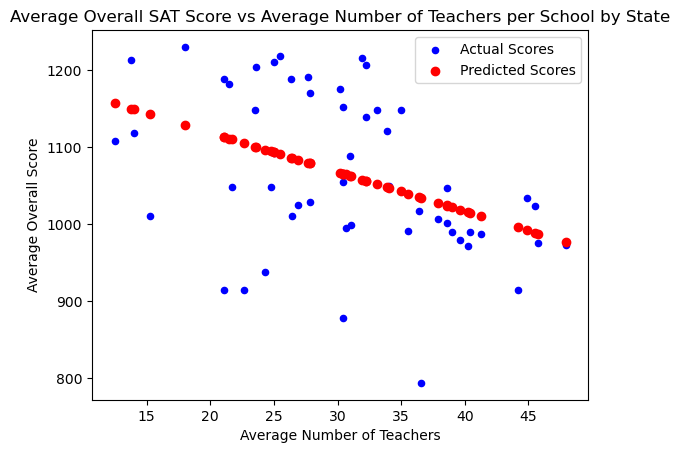

In [19]:
scores = combined_sat_2014.Total_Overall_Score
teachers = combined_sat_2014[["Avg_Teachers"]]
scores_teachers_lm = LinearRegression().fit(teachers, scores)
scores_teachers_plot = combined_sat_2014.plot.scatter(x = "Avg_Teachers", y = "Total_Overall_Score", color = "blue", label = "Actual Scores")
scores_teachers_plot.scatter(combined_sat_2014["Avg_Teachers"], 
                             scores_teachers_lm.predict(combined_sat_2014[["Avg_Teachers"]]), color="red", label="Predicted Scores")
scores_teachers_plot.legend()
scores_teachers_plot.set_xlabel("Average Number of Teachers")
scores_teachers_plot.set_ylabel("Average Overall Score")
scores_teachers_plot.set_title("Average Overall SAT Score vs Average Number of Teachers per School by State")
print("R squared: ", scores_teachers_lm.score(teachers, scores))
print("Correlation: ", combined_sat_2014.Avg_Teachers.corr(scores))

From the plot, we can see that there is a weak negative relationship between the average number of teachers and the average overall SAT score, and the relationship likely isn't strong enough to serve as a predictor. A better measure could possibly be the average student to teacher ratio for each state. After all, it doesn't mean much to have a lot of teachers if there's such a large amount of students they have to manage; a smaller student-to-teacher ratio could indicate that teachers would be able to give more one-on-one attention and prep to students.

R squared:  0.0016072751228832782
Correlation:  0.0400908358965424


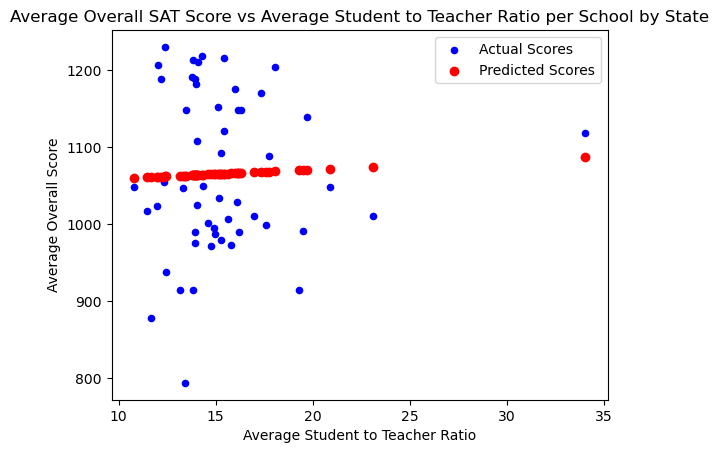

In [21]:
ratio = combined_sat_2014[["Avg_Student_Teacher_Ratio"]]
scores_ratio_lm = LinearRegression().fit(ratio, scores)
scores_ratio_plot = combined_sat_2014.plot.scatter(x = "Avg_Student_Teacher_Ratio", y = "Total_Overall_Score", color = "blue", 
                                                   label = "Actual Scores")
scores_ratio_plot.scatter(combined_sat_2014["Avg_Student_Teacher_Ratio"], 
                             scores_ratio_lm.predict(combined_sat_2014[["Avg_Student_Teacher_Ratio"]]), color="red", label="Predicted Scores")
scores_ratio_plot.legend()
scores_ratio_plot.set_xlabel("Average Student to Teacher Ratio")
scores_ratio_plot.set_ylabel("Average Overall Score")
scores_ratio_plot.set_title("Average Overall SAT Score vs Average Student to Teacher Ratio per School by State")
print("R squared: ", scores_ratio_lm.score(ratio, scores))
print("Correlation: ", combined_sat_2014.Avg_Student_Teacher_Ratio.corr(scores))

Unfortunately, average the student to teacher ratio is a worse predictor than the average number of teachers, having esstentially no relationship with the average SAT score. Another possible predictor to try is the number of test takers by state.

R squared:  0.12058130764889496
Correlation:  -0.34724819315425515


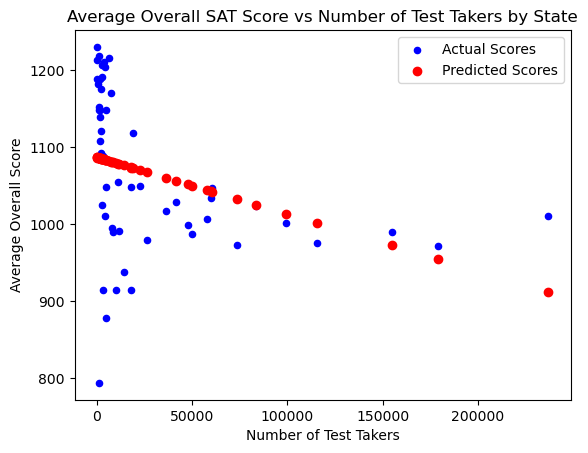

In [23]:
takers = combined_sat_2014[["Total.Test-takers"]]
scores_takers_lm = LinearRegression().fit(takers, scores)
scores_takers_plot = combined_sat_2014.plot.scatter(x = "Total.Test-takers", y = "Total_Overall_Score", color = "blue", 
                                                   label = "Actual Scores")
scores_takers_plot.scatter(combined_sat_2014["Total.Test-takers"], 
                             scores_takers_lm.predict(combined_sat_2014[["Total.Test-takers"]]), color="red", label="Predicted Scores")
scores_takers_plot.legend()
scores_takers_plot.set_ylabel("Average Overall Score")
scores_takers_plot.set_xlabel("Number of Test Takers")
scores_takers_plot.set_title("Average Overall SAT Score vs Number of Test Takers by State")
print("R squared: ", scores_takers_lm.score(takers, scores))
print("Correlation: ", takers["Total.Test-takers"].corr(scores))

From the plot, we see a weak, negative relationship between the number of test takers and the average overall SAT score. We can notice that it does seem that the average score does tend down as the number of test takers increases, but any relationship is muddled by the fact that most states have such a relatively low amount of test takers. Perhaps if we had the proportion of students who took the SAT out of all students eligible to take the test, we could find a stronger negative relationship.

We then move on to checking how the gender distribution of the test takers affects the overall SAT score.

R squared:  0.03440305974076874
Correlation:  -0.18548061823481382


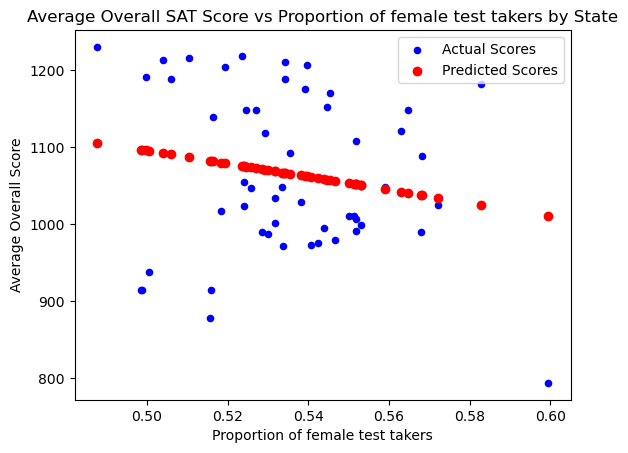

In [25]:
female = combined_sat_2014[["Gender.Female.Test-takers"]]
scores_female_lm = LinearRegression().fit(female, scores)
scores_female_plot = combined_sat_2014.plot.scatter(x = "Gender.Female.Test-takers", y = "Total_Overall_Score", color = "blue", 
                                                   label = "Actual Scores")
scores_female_plot.scatter(combined_sat_2014["Gender.Female.Test-takers"], 
                             scores_female_lm.predict(combined_sat_2014[["Gender.Female.Test-takers"]]), color="red", 
                           label="Predicted Scores")
scores_female_plot.legend()
scores_female_plot.set_ylabel("Average Overall Score")
scores_female_plot.set_xlabel("Proportion of female test takers")
scores_female_plot.set_title("Average Overall SAT Score vs Proportion of female test takers by State")
print("R squared: ", scores_female_lm.score(female, scores))
print("Correlation: ", female["Gender.Female.Test-takers"].corr(scores))

R squared:  0.034403059740768516
Correlation:  0.18548061823481382


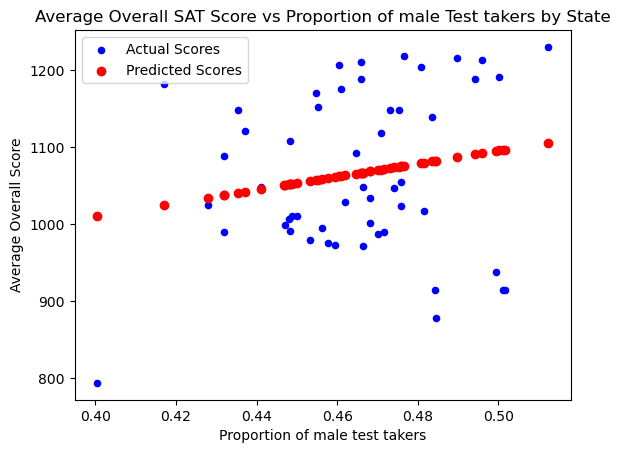

In [26]:
male = combined_sat_2014[["Gender.Male.Test-takers"]]
scores_male_lm = LinearRegression().fit(male, scores)
scores_male_plot = combined_sat_2014.plot.scatter(x = "Gender.Male.Test-takers", y = "Total_Overall_Score", color = "blue", 
                                                   label = "Actual Scores")
scores_male_plot.scatter(combined_sat_2014["Gender.Male.Test-takers"], 
                             scores_male_lm.predict(combined_sat_2014[["Gender.Male.Test-takers"]]), color="red", 
                           label="Predicted Scores")
scores_male_plot.legend()
scores_male_plot.set_ylabel("Average Overall Score")
scores_male_plot.set_xlabel("Proportion of male test takers")
scores_male_plot.set_title("Average Overall SAT Score vs Proportion of male Test takers by State")
print("R squared: ", scores_male_lm.score(male, scores))
print("Correlation: ", male["Gender.Male.Test-takers"].corr(scores))

From the plots, there is a weak negative relationship between the propertion of female test takers and the state average overall SAT score, and a weak positive relationship between the propertion of female test takers and the state average overall SAT score. Intrestingly, these relationships mirror each other, with the same R squared value.

**Evan**  <br>
So, for the 6 subjects that is included with our dataset that students took, they each include subject-specific average GPAs ranging from 0.0-4.0 for a school year. Our goal is to see if Average GPA on a subject by subject basis is a significant predictor in SAT scores.   <br> <br>
We will start by getting the R² values and correlation for each subject, and then making a scatter plot for each subject.

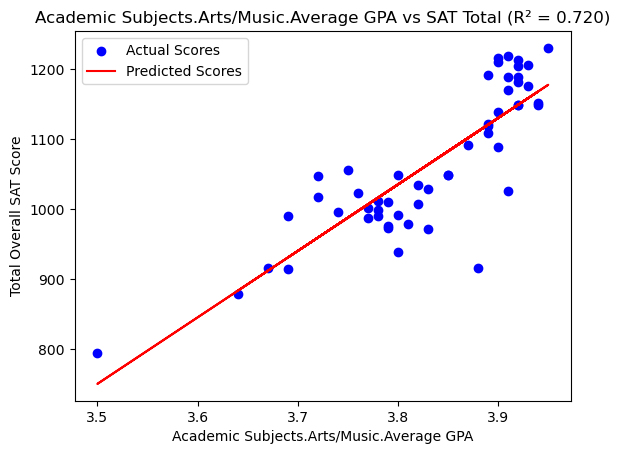

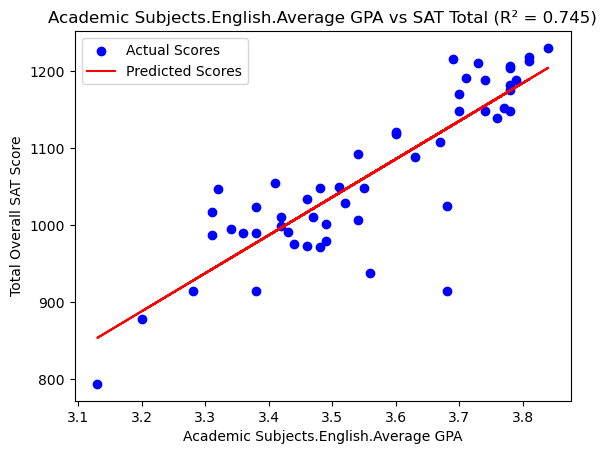

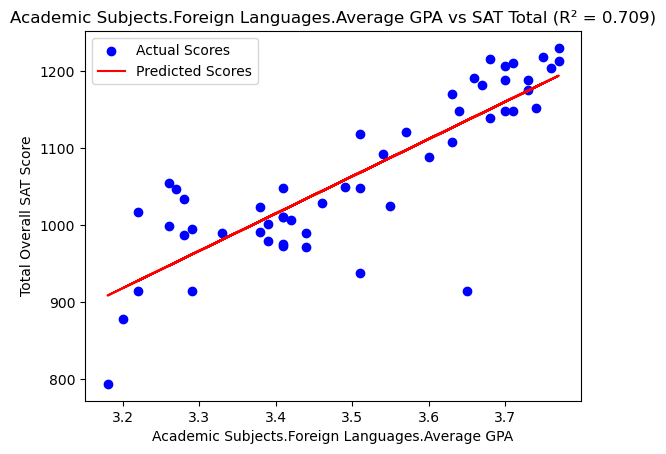

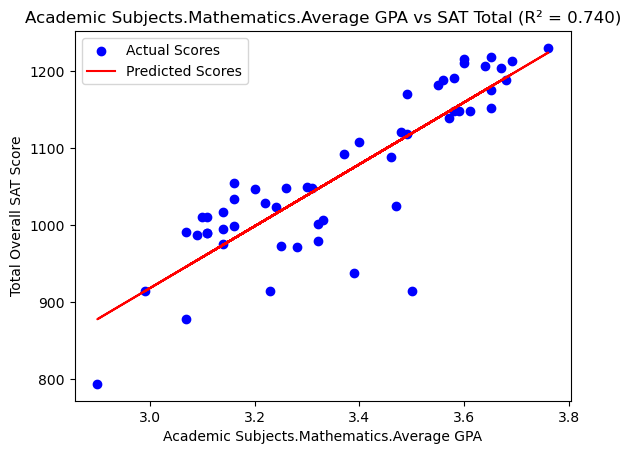

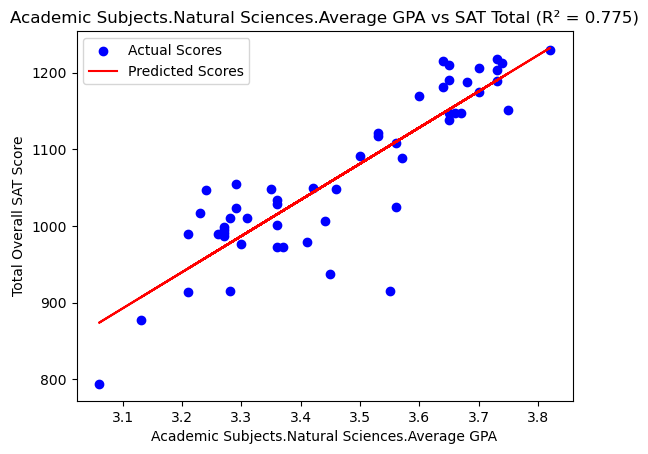

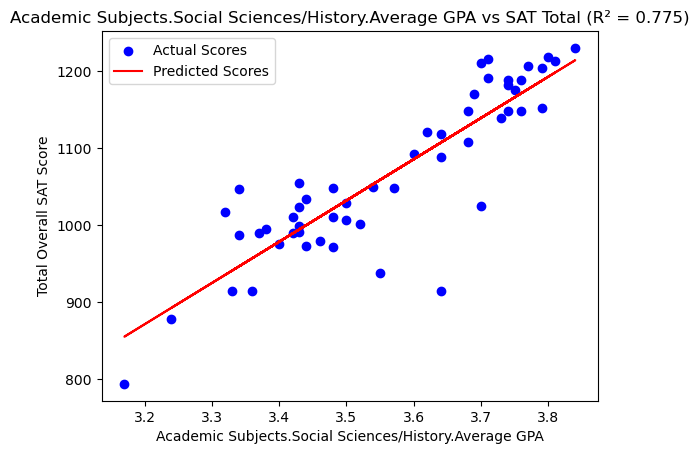

                                             Subject        R²  Correlation
0           Academic Subjects.Arts/Music.Average GPA  0.720112     0.848594
1              Academic Subjects.English.Average GPA  0.744926     0.863091
2    Academic Subjects.Foreign Languages.Average GPA  0.708813     0.841911
3          Academic Subjects.Mathematics.Average GPA  0.739784     0.860107
4     Academic Subjects.Natural Sciences.Average GPA  0.775284     0.880502
5  Academic Subjects.Social Sciences/History.Aver...  0.774933     0.880303


In [29]:
subjects = ["Academic Subjects.Arts/Music.Average GPA",
            "Academic Subjects.English.Average GPA",
            "Academic Subjects.Foreign Languages.Average GPA",
            "Academic Subjects.Mathematics.Average GPA",
            "Academic Subjects.Natural Sciences.Average GPA",
            "Academic Subjects.Social Sciences/History.Average GPA"]

scores = sat_data_2014["Total_Overall_Score"]

results = []

for subj in subjects:
    X_subj = sat_data_2014[[subj]]
    lm = LinearRegression().fit(X_subj, scores)
    r2 = lm.score(X_subj, scores)
    corr = numpy.sqrt(r2) if lm.coef_[0] > 0 else -np.sqrt(r2)
    results.append((subj, r2, corr))


    plt.figure()
    plt.scatter(X_subj, scores, color="blue", label="Actual Scores")
    plt.plot(X_subj, lm.predict(X_subj), color="red", label="Predicted Scores")
    plt.xlabel(subj)
    plt.ylabel("Total Overall SAT Score")
    plt.title(f"{subj} vs SAT Total (R² = {r2:.3f})")
    plt.legend()
    plt.show()


results_df = pandas.DataFrame(results, columns=["Subject", "R²", "Correlation"])
print(results_df)

From those graphs and tables, we can determine that all subjects have a strong positive trend, showing that having a higher GPA yields a higher SAT score. We can additionally see that all R² values range from 0.70 to 0.77, which correlates to how much of the variability can be explained by each subject independently, with Natural Sciences having the highest at 77.5%. <br> <br> This was expected, as having more knowledge on math for example, **should** statistically improve your score on the Math section, and vice-versa. <br> <br> We'd also like to see how scores are affected with all Average GPAs combined, with a multi linear regression.

Overall R² (all GPAs together): 0.7975581049720198


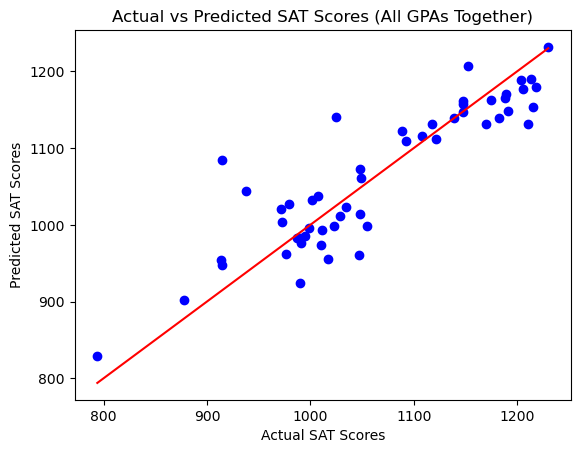

In [31]:
y = sat_data_2014["Total_Overall_Score"]

X = sat_data_2014[["Academic Subjects.Arts/Music.Average GPA",
                   "Academic Subjects.English.Average GPA",
                   "Academic Subjects.Foreign Languages.Average GPA",
                   "Academic Subjects.Mathematics.Average GPA",
                   "Academic Subjects.Natural Sciences.Average GPA",
                   "Academic Subjects.Social Sciences/History.Average GPA"]]

model = LinearRegression().fit(X, y)
print("Overall R² (all GPAs together):", model.score(X, y))

# scatter
y_pred = model.predict(X)

plt.scatter(y, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel("Actual SAT Scores")
plt.ylabel("Predicted SAT Scores")
plt.title("Actual vs Predicted SAT Scores (All GPAs Together)")
plt.show()

This shows the overall scores based on all GPAs, and we can see the similar positive trend here. Main thing to note is the slightly higher R² value of 0.798, which shows that this regression explains about 80% of the variation in average SAT scores.

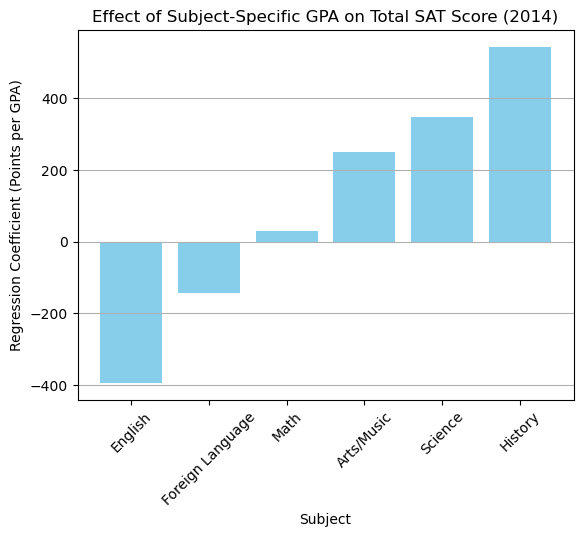

,Subject,Coefficient
1,English,-393.678541
2,Foreign Language,-142.361981
3,Math,30.419971
0,Arts/Music,248.344211
4,Science,347.520441
5,History,542.555271


In [33]:
subject_labels = {"Academic Subjects.Arts/Music.Average GPA": "Arts/Music",
                  "Academic Subjects.English.Average GPA": "English",
                  "Academic Subjects.Foreign Languages.Average GPA": "Foreign Language",
                  "Academic Subjects.Mathematics.Average GPA": "Math",
                  "Academic Subjects.Natural Sciences.Average GPA": "Science",
                  "Academic Subjects.Social Sciences/History.Average GPA": "History"
}

coef_table = pandas.DataFrame({ "Subject": X.columns.map(subject_labels),
                               "Coefficient": model.coef_}).sort_values(by="Coefficient", ascending=True)

plt.bar(coef_table["Subject"], coef_table["Coefficient"], color="skyblue")
plt.title("Effect of Subject-Specific GPA on Total SAT Score (2014)")
plt.ylabel("Regression Coefficient (Points per GPA)")
plt.xlabel("Subject")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

coef_table

Lastly, this graph shows the type of relationship each subject has with SAT scores, with History having the strongest positive relationship and English having the strongest negative relationship. This is very shocking, as the two categories for the SAT are Math and Verbal (Reading/English), so you would think that those categories would be higher, but this data would indicate the opposite is true.

**Question: (Cheyenne)** <br>
How does average number of years of instruction in each subject (Arts/Music, Foreign Languages, Mathematics, Natural Sciences, Social Sciences/History) affect SAT score. Are certain catogories more predictive in SAT scores than others?

We will first look at how the average number of years of instruction in each subject relates to SAT scores and evaluate the performace of said catogory in a linear model. Depending on the results, we could then perhpaps consider a model that uses each subject.

In [36]:
arts_music = combined_sat_2014[["Academic Subjects.Arts/Music.Average Years"]]
english = combined_sat_2014[["Academic Subjects.English.Average Years"]]
foreign_langauge = combined_sat_2014[["Academic Subjects.Foreign Languages.Average Years"]]
math = combined_sat_2014[['Academic Subjects.Mathematics.Average Years']]
science = combined_sat_2014[['Academic Subjects.Natural Sciences.Average Years']]
history = combined_sat_2014[['Academic Subjects.Social Sciences/History.Average Years']]

**correlation heatmap showing relationship between years of experience in subject catagory and SAT scores:**

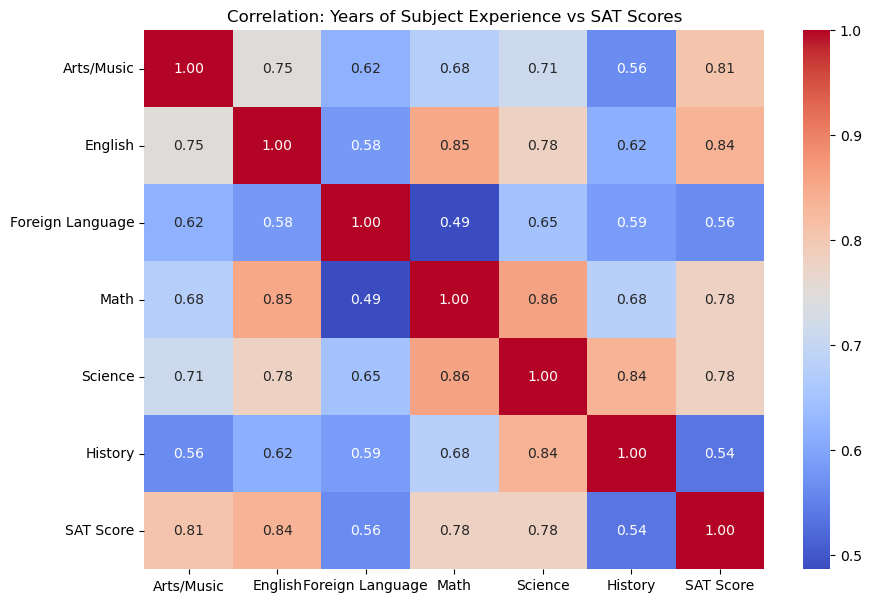

In [38]:
#heatmap

#build data frame
df_corr = combined_sat_2014[[
    "Academic Subjects.Arts/Music.Average Years",
    "Academic Subjects.English.Average Years",
    "Academic Subjects.Foreign Languages.Average Years",
    "Academic Subjects.Mathematics.Average Years",
    "Academic Subjects.Natural Sciences.Average Years",
    "Academic Subjects.Social Sciences/History.Average Years",
    "Total_Overall_Score"   # <-- Change this to whatever column your SAT score is
]]

df_corr.columns = [
    "Arts/Music",
    "English",
    "Foreign Language",
    "Math",
    "Science",
    "History",
    "SAT Score"
]
#cor matrix 
corr_matrix = df_corr.corr()

#plot
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: Years of Subject Experience vs SAT Scores")
plt.show()


R squared:  0.6528959619504291
Correlation:  0.8080197781926065


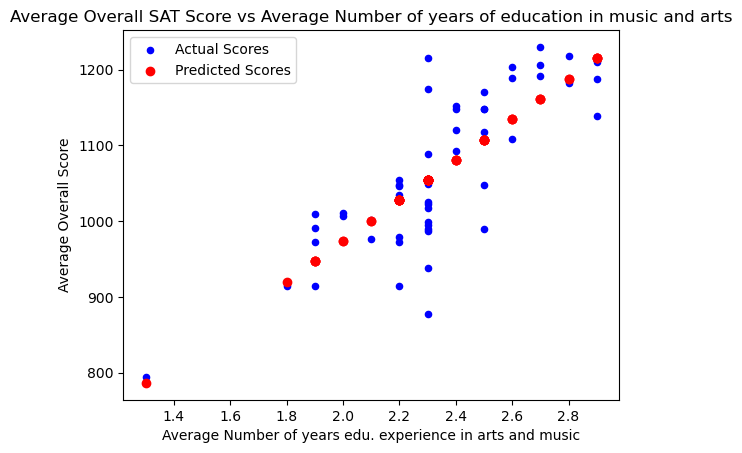

In [39]:
# regression for arts and music 

arts_lm = LinearRegression().fit(arts_music, scores)
arts_years_plot = combined_sat_2014.plot.scatter(x = "Academic Subjects.Arts/Music.Average Years", y = "Total_Overall_Score", color = "blue", label = "Actual Scores")
arts_years_plot.scatter(combined_sat_2014["Academic Subjects.Arts/Music.Average Years"], 
                             arts_lm.predict(combined_sat_2014[["Academic Subjects.Arts/Music.Average Years"]]), color="red", label="Predicted Scores")
arts_years_plot.legend()
arts_years_plot.set_xlabel("Average Number of years edu. experience in arts and music")
arts_years_plot.set_ylabel("Average Overall Score")
arts_years_plot.set_title("Average Overall SAT Score vs Average Number of years of education in music and arts")
print("R squared: ", arts_lm.score(arts_music, scores))
print("Correlation: ", numpy.sqrt( arts_lm.score(arts_music, scores)))

This shows that the predictor "Average years of arts/music teaching" explains 65.29 % variability in average overall SAT scores. Additionally, we can notice that there is a strong positive correlation (.81) between average overall sat score and the average number of years of eduction in this subject. Although music and arts are not a catagory in the SAT, this shows that as years of education in art and music increases, so does SAT scores. However, this trend could be a very broad one as it is known that longer years of education leads to higher testing scores. <br>
Because of this "universal law" that scores will increases as years of education increase, we will look at a linear model that considers all 6 subjects to see which topic score is most sensitive to and by how much.

In [41]:
#considering all 6 subjects as good predictors. 

X = pandas.concat(
    [arts_music, english, foreign_langauge, math, science, history], 
    axis=1
)
all_lm = LinearRegression().fit(X, scores)
# overall r sqaured
y = scores  # assuming this is your target Series
print("Full Model R²:", all_lm.score(X, y))

y_pred = all_lm.predict(X)



X.columns = [
    "Arts/Music Years",
    "English Years",
    "Foreign Lang. Years",
    "Math Years",
    "Science Years",
    "History Years"
]
print("Slope estimations (beta) for each predictor:")
print("")
for name, coef in zip(X.columns, all_lm.coef_):
    print(f"{name}: {coef}")
print("")
print("correlation between each predictor and scores")
print("")
for col in X.columns:
    corr = X[col].corr(scores)
    print(f"{col}: {corr}")

Full Model R²: 0.8181788364569621
Slope estimations (beta) for each predictor:

Arts/Music Years: 115.77077948549307
English Years: 336.9964946345276
Foreign Lang. Years: -5.828228383486675
Math Years: 9.699305643798823
Science Years: 217.60089786717785
History Years: -148.60970353658138

correlation between each predictor and scores

Arts/Music Years: nan
English Years: nan
Foreign Lang. Years: nan
Math Years: nan
Science Years: nan
History Years: nan


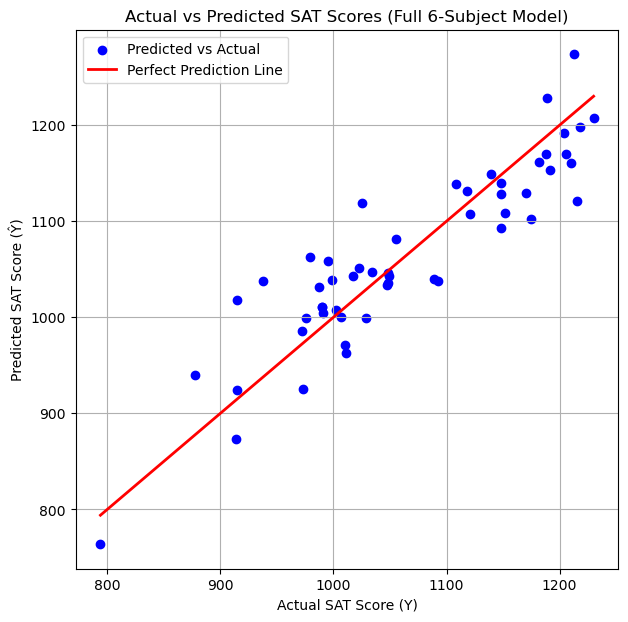

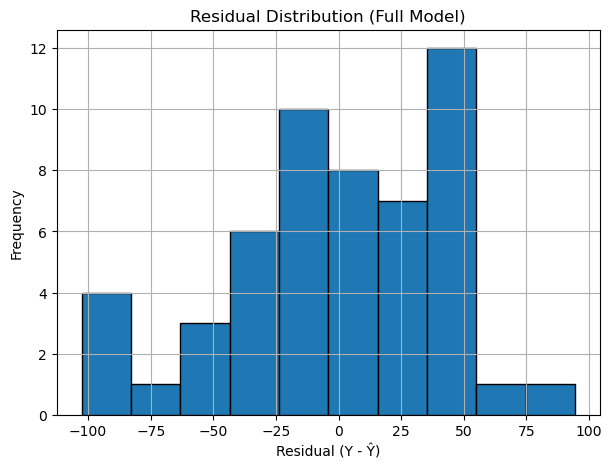

R²:   0.8182
MAE:  35.6088
RMSE: 43.8525
Bias: -0.0000


In [42]:
# checking prediction versus observed value

X = pandas.concat(
    [arts_music, english, foreign_langauge, math, science, history], 
    axis=1
)
all_lm = LinearRegression().fit(X, scores)

y_arr    = numpy.asarray(y).ravel()          # actual
yhat_arr = numpy.asarray(y_pred).ravel()     # predicted from all_lm

# Scatter + 45° perfect-fit line
plt.figure(figsize=(7, 7))
plt.scatter(y_arr, yhat_arr, color="blue", label="Predicted vs Actual")
lo, hi = y_arr.min(), y_arr.max()
plt.plot([lo, hi], [lo, hi], color="red", linewidth=2, label="Perfect Prediction Line")
plt.xlabel("Actual SAT Score (Y)")
plt.ylabel("Predicted SAT Score (Ŷ)")
plt.title("Actual vs Predicted SAT Scores (Full 6-Subject Model)")
plt.legend()
plt.grid(True)
plt.show()

# Error metrics
mae  = numpy.mean(numpy.abs(y_arr - yhat_arr))
rmse = numpy.sqrt(numpy.mean((y_arr - yhat_arr)**2))
bias = numpy.mean(yhat_arr - y_arr)  # positive = overpredict on average
r2   = all_lm.score(X, y)         # same as printed earlier; safe to recompute

#residuals 
residuals = y_arr - yhat_arr
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=10, edgecolor="black")
plt.xlabel("Residual (Y - Ŷ)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Full Model)")
plt.grid(True)
plt.show()

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Bias: {bias:.4f}")


This full model performs slightly better than just using the art predictor in terms of R squared. However, the negative negative beta estimation for Foreign Lang and History predicors along with there relatively low correlation to overall SAT scores might suggest that the model may perform better in predictions without considering foreign lang. and history. Below we will try a model without History and Foreign Language and evaluate. 

In [44]:
#four subject model  
X = pandas.concat(
    [arts_music, english, math, science ], 
    axis=1
)
X.columns = [
    "Arts/Music Years",
    "English Years",
    "Math Years",
    "Science Years"
]
partial_lm = LinearRegression().fit(X, scores)

y = scores  # assuming this is your target Series
# overall r sqaured
print("partial Model R²:", partial_lm.score(X, y))

y_pred = partial_lm.predict(X)


print("Slope estimations (beta) for each predictor:")
for name, coef in zip(X.columns, all_lm.coef_):
    print(f"{name}: {coef}")
print("")
print("correlation between each predictor and scores")
for col in X.columns:
    corr = X[col].corr(scores)
    print(f"{col}: {corr}")

partial Model R²: 0.7912571548653383
Slope estimations (beta) for each predictor:
Arts/Music Years: 115.77077948549307
English Years: 336.9964946345276
Math Years: -5.828228383486675
Science Years: 9.699305643798823

correlation between each predictor and scores
Arts/Music Years: nan
English Years: nan
Math Years: nan
Science Years: nan


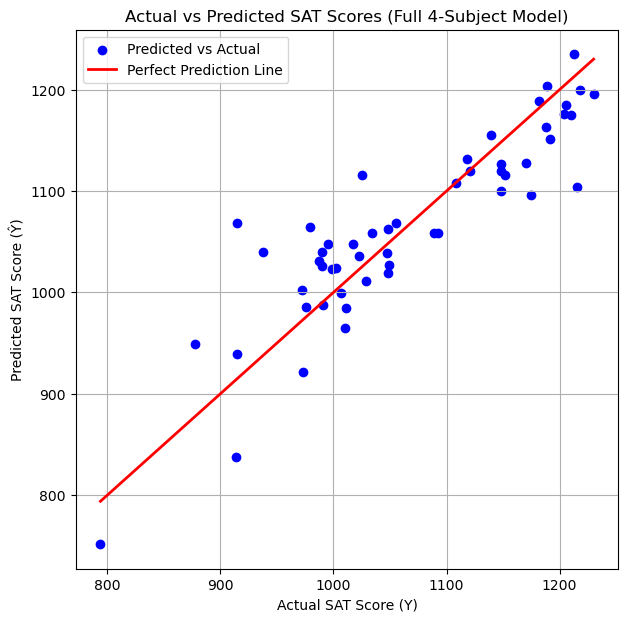

R² (partial model): 0.7912571548653383
MAE: 36.33545343245638
RMSE: 46.98698109982015
Mean Error (Bias): -3.7752610262272495e-13

Slope estimates (betas):
Arts/Music Years: 118.07740767233463
English Years: 333.63070133326926
Math Years: 36.35342660866591
Science Years: 79.49876156993727


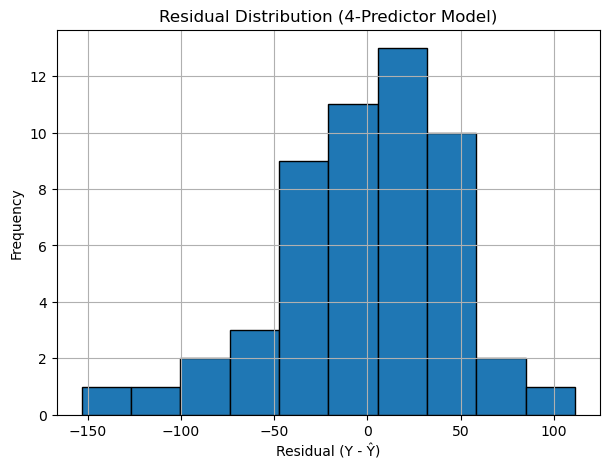

In [45]:
# checking prediction versus observed value

# --- Predictions ---
# Ensure y is a 1-D Series
y = scores.squeeze()                 # makes it a Series
y_hat = partial_lm.predict(X)        # numpy array shape (n,)

# --- Y vs Ŷ plot ---

# Convert to plain 1-D arrays for plotting safety
y_arr = numpy.asarray(y).ravel()
yhat_arr = numpy.asarray(y_hat).ravel()

plt.figure(figsize=(7, 7))
plt.scatter(y_arr, yhat_arr, color="blue", label="Predicted vs Actual")

# 45-degree reference line
lo, hi = y_arr.min(), y_arr.max()
plt.plot([lo, hi], [lo, hi], color="red", linewidth=2, label="Perfect Prediction Line")

plt.xlabel("Actual SAT Score (Y)")
plt.ylabel("Predicted SAT Score (Ŷ)")
plt.title("Actual vs Predicted SAT Scores (Full 4-Subject Model)")
plt.legend()
plt.grid(True)
plt.show()

# --- Errors / metrics ---
mae  = numpy.mean(numpy.abs(y_arr - yhat_arr))
rmse = numpy.sqrt(numpy.mean((y_arr - yhat_arr)**2))
bias = numpy.mean(yhat_arr - y_arr)

print("R² (partial model):", partial_lm.score(X, y))  # okay to compute now that y is defined
print("MAE:", mae)
print("RMSE:", rmse)
print("Mean Error (Bias):", bias)

# --- Coefficients paired with predictor names (use the right model) ---
print("\nSlope estimates (betas):")
for name, coef in zip(X.columns, partial_lm.coef_):
    print(f"{name}: {coef}")

#  Residual Histogram
# --------------------------------
residuals = y_arr - yhat_arr
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=10, edgecolor="black")
plt.xlabel("Residual (Y - Ŷ)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (4-Predictor Model)")
plt.grid(True)
plt.show()

Based on the error metrics and R² values, the full six-predictor model performs better than the reduced model that excluded History and Foreign Languages. This indicates that one or both of these predictors still contribute meaningful information to the regression, even if their individual correlations with SAT scores are relatively low. It also suggests the presence of multicollinearity: when we removed these predictors, the remaining variables could not fully account for the variation in SAT scores. <br>
Since History shows the weakest simple correlation with scores, we will fit one additional model that excludes only the History predictor. This may capture a possible trade-off effect, where increases in History instruction time correspond to decreases in higher-ROI subjects such as Mathematics or Science. Comparing this model to the full model will help determine whether History is contributing useful predictive information or simply adding noise.

Reduced Model R²: 0.7923533492570304
Slope estimations (beta) for each predictor:
Arts/Music Years: 115.77077948549307
English Years: 336.9964946345276
Foreign Lang. Years: -5.828228383486675
Math Years: 9.699305643798823
Science Years: 217.60089786717785

Error Metrics for 5-Predictor Model:
R²:   0.7924
MAE:  35.9959
RMSE: 46.8634
Bias: -2.7027e-13


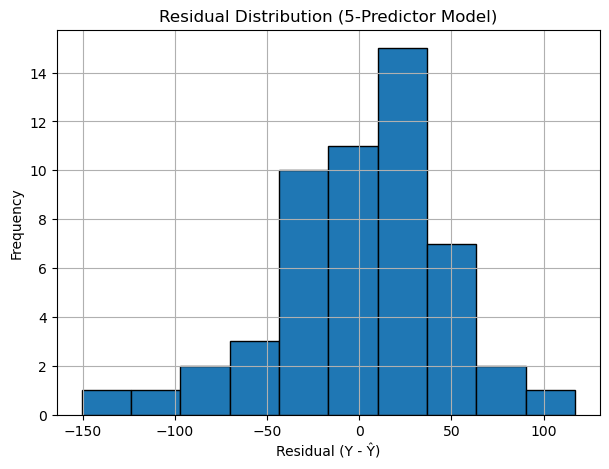

In [47]:
X = pandas.concat(
    [arts_music, english, foreign_langauge, math, science], 
    axis=1
)
X.columns = [
    "Arts/Music Years",
    "English Years",
    "Foreign Lang. Years",
    "Math Years",
    "Science Years"
]
reduced_lm = LinearRegression().fit(X, scores)
# overall r sqaured
print("Reduced Model R²:", reduced_lm.score(X, y))

y = scores  # assuming this is your target Series
y_pred = reduced_lm.predict(X)


print("Slope estimations (beta) for each predictor:")
for name, coef in zip(X.columns, all_lm.coef_):
    print(f"{name}: {coef}")

# ----- Error Metrics for the 5-Predictor Model -----

import numpy as np

# Ensure arrays are 1-D
y_arr    = numpy.asarray(y).ravel()
yhat_arr = numpy.asarray(y_pred).ravel()

# Compute metrics
r2   = reduced_lm.score(X, y)
mae  = numpy.mean(numpy.abs(y_arr - yhat_arr))
rmse = numpy.sqrt(numpy.mean((y_arr - yhat_arr)**2))
bias = numpy.mean(yhat_arr - y_arr)

print("\nError Metrics for 5-Predictor Model:")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Bias: {bias:.4e}")   # scientific notation for very small numbers

#  Residual Histogram
# --------------------------------
residuals = y_arr - yhat_arr
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=10, edgecolor="black")
plt.xlabel("Residual (Y - Ŷ)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (5-Predictor Model)")
plt.grid(True)
plt.show()

The full model had the highest R² (0.8182) and lowest RMSE (43.85), but the improvements over the reduced models were extremely small. Both the 5-predictor model (R² = 0.7924, RMSE = 46.86) and the 4-predictor model (R² = 0.7913, RMSE = 46.99) performed only slightly worse despite using fewer predictors. All models showed near-zero bias, indicating predictions are not systematically over- or under-estimating SAT scores.
When History and Foreign Language were removed, the 4-predictor model produced positive, stable, and interpretable coefficients, consistent with the expected direction that more years of instruction should be associated with higher SAT scores.
**residual diagnostics** <br>
 -The full model showed heavier tails and more extreme residuals, indicating mild overfitting.<br>
 -The 5-predictor model improved slightly but still displayed a wide spread of errors.<br>
 -The 4-predictor model had the most symmetric and centered residual distribution, with fewer large outliers and a shape closer to normal error <br>behavior.<br>
This suggests that removing the two least informative predictors made the model more balanced and less noisy.
<br>
Our final choice was the 4-predictor model. Although the full model had the highest R squared, the improvement is too small to justify including predictors that contribute minally to explained variatiion in test scores, introduce multicollinearity, and lack theoretical justification.
The 4-predictor model preserves almost all predictive power while improving interpretability and producing cleaner residuals.

**Family Income Predictors - Ziad** <br>



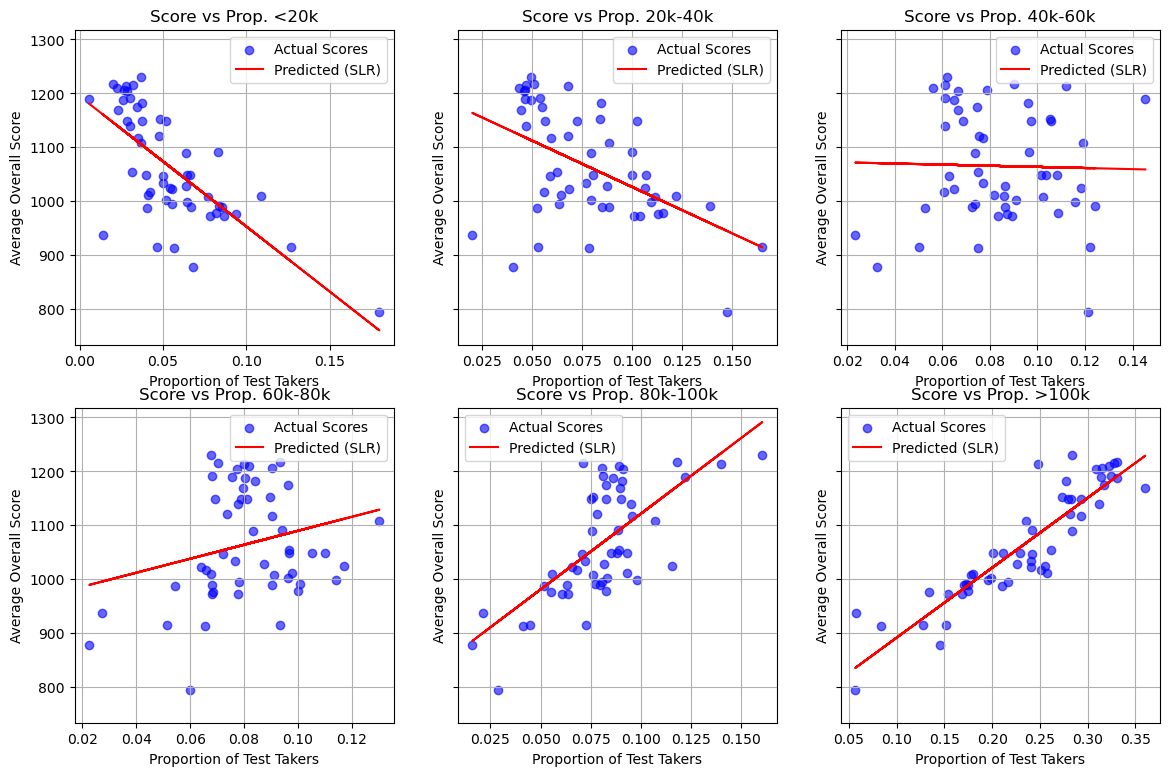

Individual Predictor Metrics
                R squared  Correlation
Income Bracket                        
<20k               0.4968      -0.7048
20k-40k            0.2480      -0.4980
40k-60k            0.0006      -0.0245
60k-80k            0.0593       0.2435
80k-100k           0.4770       0.6907
>100k              0.8192       0.9051


In [50]:
income_brackets_full = ["Family Income.Less than 20k.Test-takers", "Family Income.Between 20-40k.Test-takers", "Family Income.Between 40-60k.Test-takers", "Family Income.Between 60-80k.Test-takers", 
                 "Family Income.Between 80-100k.Test-takers", "Family Income.More than 100k.Test-takers"]
income_brackets = {"Family Income.Less than 20k.Test-takers": "<20k", "Family Income.Between 20-40k.Test-takers": "20k-40k", 
                   "Family Income.Between 40-60k.Test-takers": "40k-60k", "Family Income.Between 60-80k.Test-takers": "60k-80k", 
                   "Family Income.Between 80-100k.Test-takers": "80k-100k", "Family Income.More than 100k.Test-takers": ">100k"}
income_df = combined_sat_2014.copy()
income_df = income_df.rename(columns = income_brackets)
income_cols_clean = list(income_brackets.values())

scores = combined_sat_2014.Total_Overall_Score

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharey=True)
axes = axes.ravel()

metrics = []

for i, col in enumerate(income_cols_clean):
    ax = axes[i]
    X_predictor = income_df[[col]]
    lm = LinearRegression().fit(X_predictor, scores)
    y_pred = lm.predict(X_predictor)

    r_squared = lm.score(X_predictor, scores)
    corr = income_df[col].corr(scores)
    metrics.append({'Income Bracket': col, 'R squared': r_squared, 'Correlation': corr})

    ax.scatter(X_predictor, scores, color='blue', label='Actual Scores', alpha=0.6)
    ax.plot(X_predictor, y_pred, color='red', label='Predicted (SLR)')
    ax.set_title(f"Score vs Prop. {col}", fontsize=12)
    ax.set_xlabel("Proportion of Test Takers", fontsize=10)
    ax.set_ylabel("Average Overall Score", fontsize=10)
    ax.legend()
    ax.grid(True)

plt.show()
metrics_df = pandas.DataFrame(metrics).set_index('Income Bracket')
print("Individual Predictor Metrics")
print(metrics_df.to_string(float_format="%.4f"))

Based on these results, we see that income has a clear relationship with SAT scores. As the proportion of test takers in the higher-income test takers, increases, the average scores increase, and vice versa for the lower-income test takers. The strongest predictors are the extremes of the income brackets. It seems like the two lowest and two highest brackets will be the most useful for our unified MLR model. 

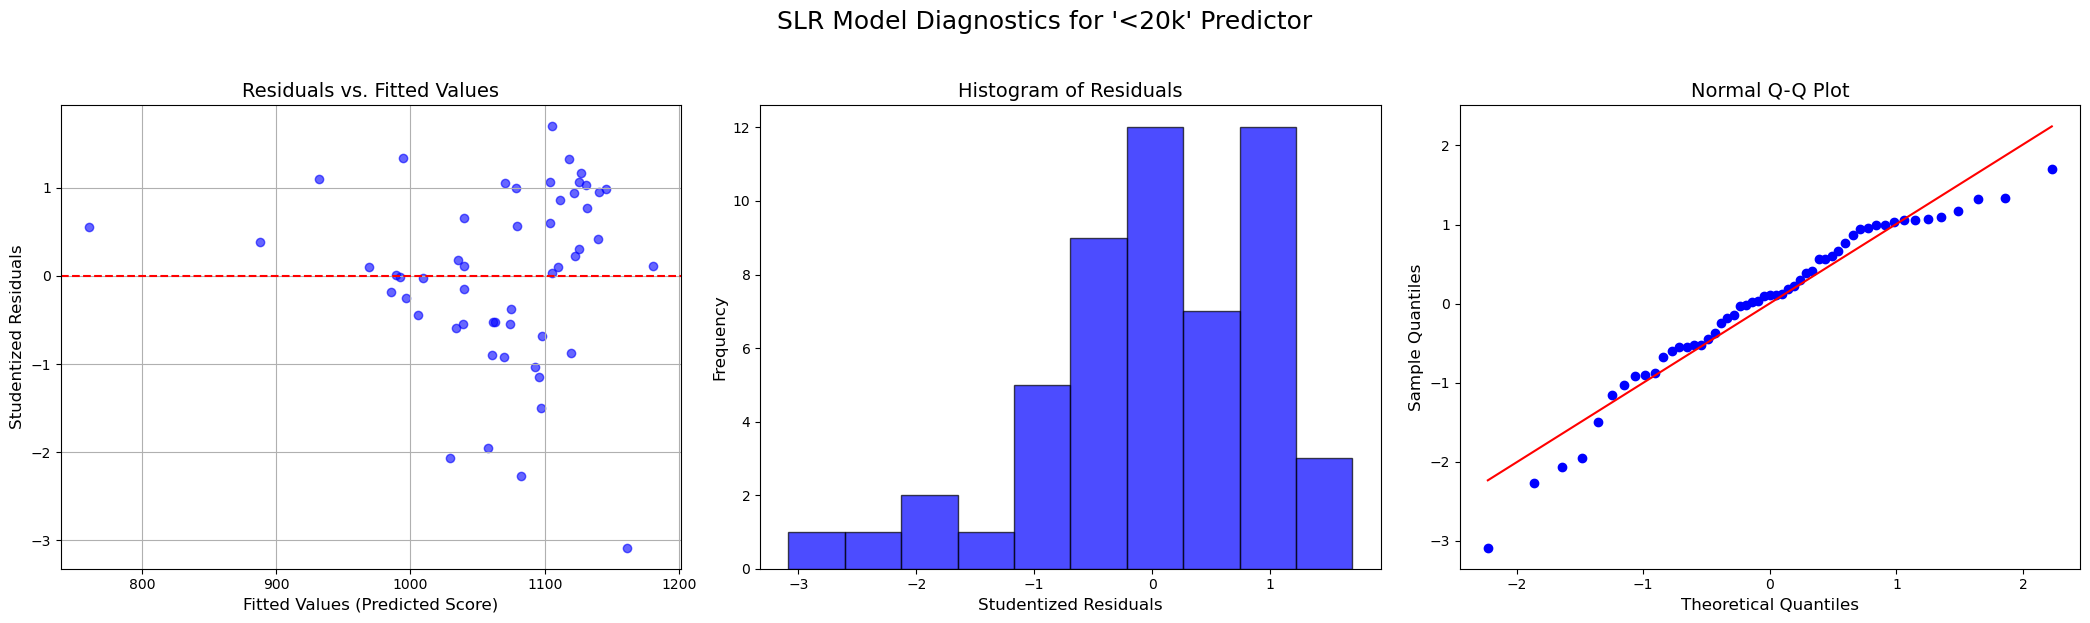

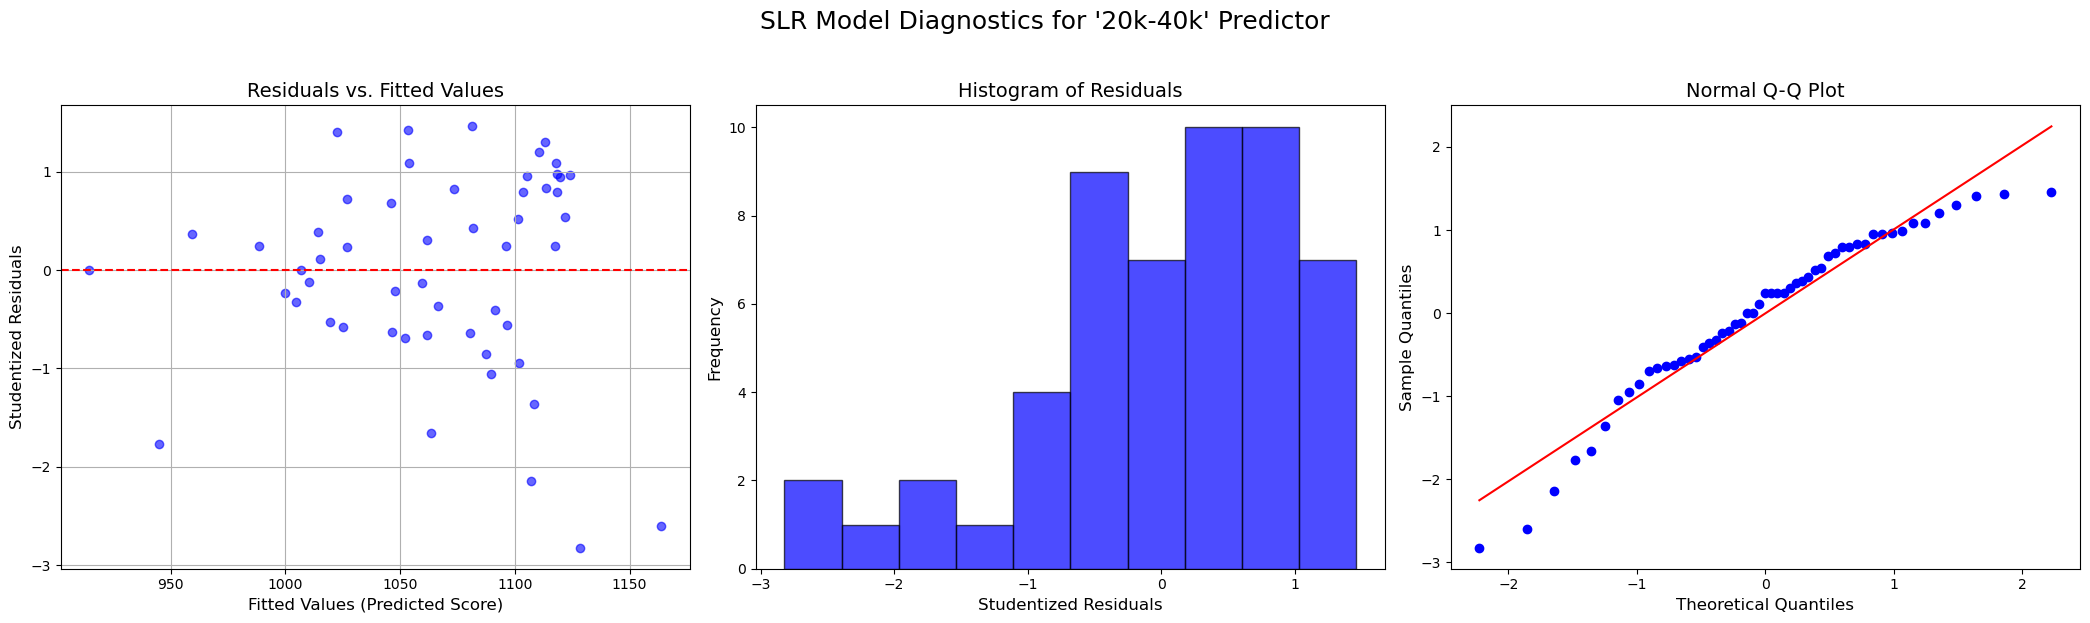

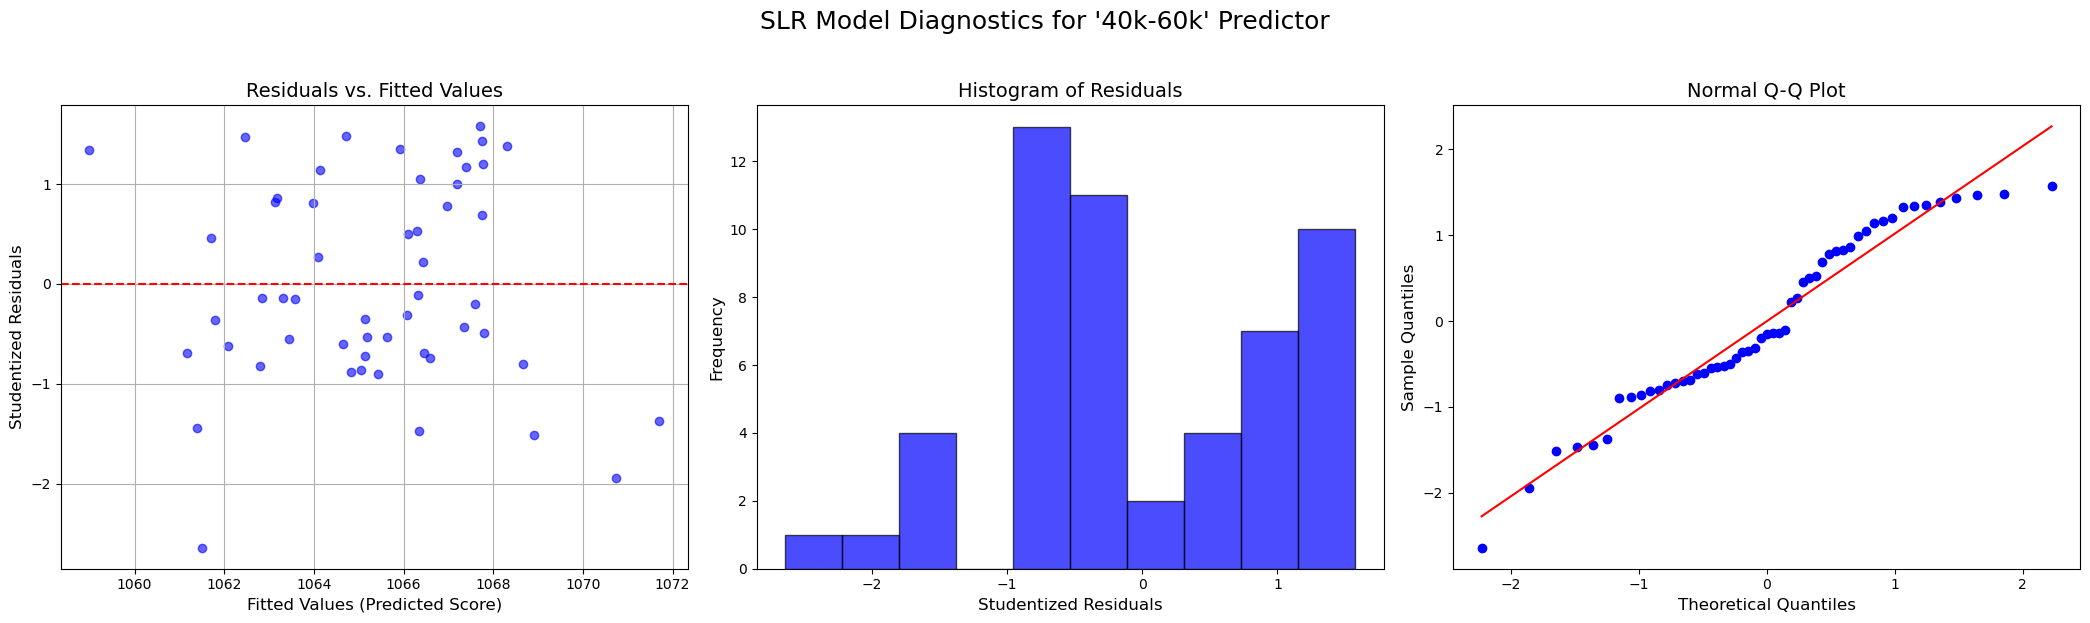

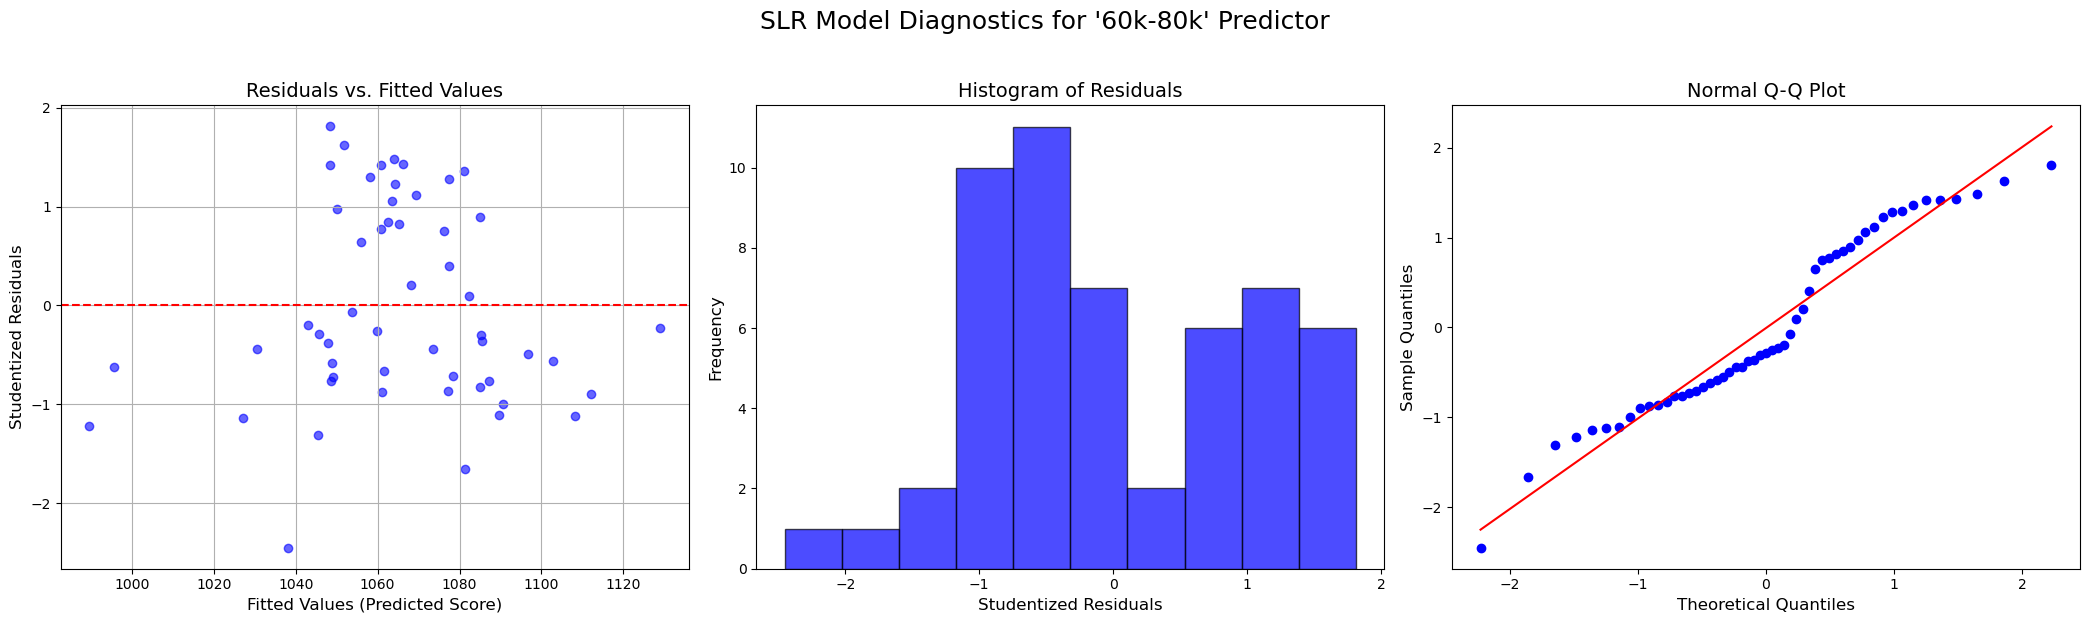

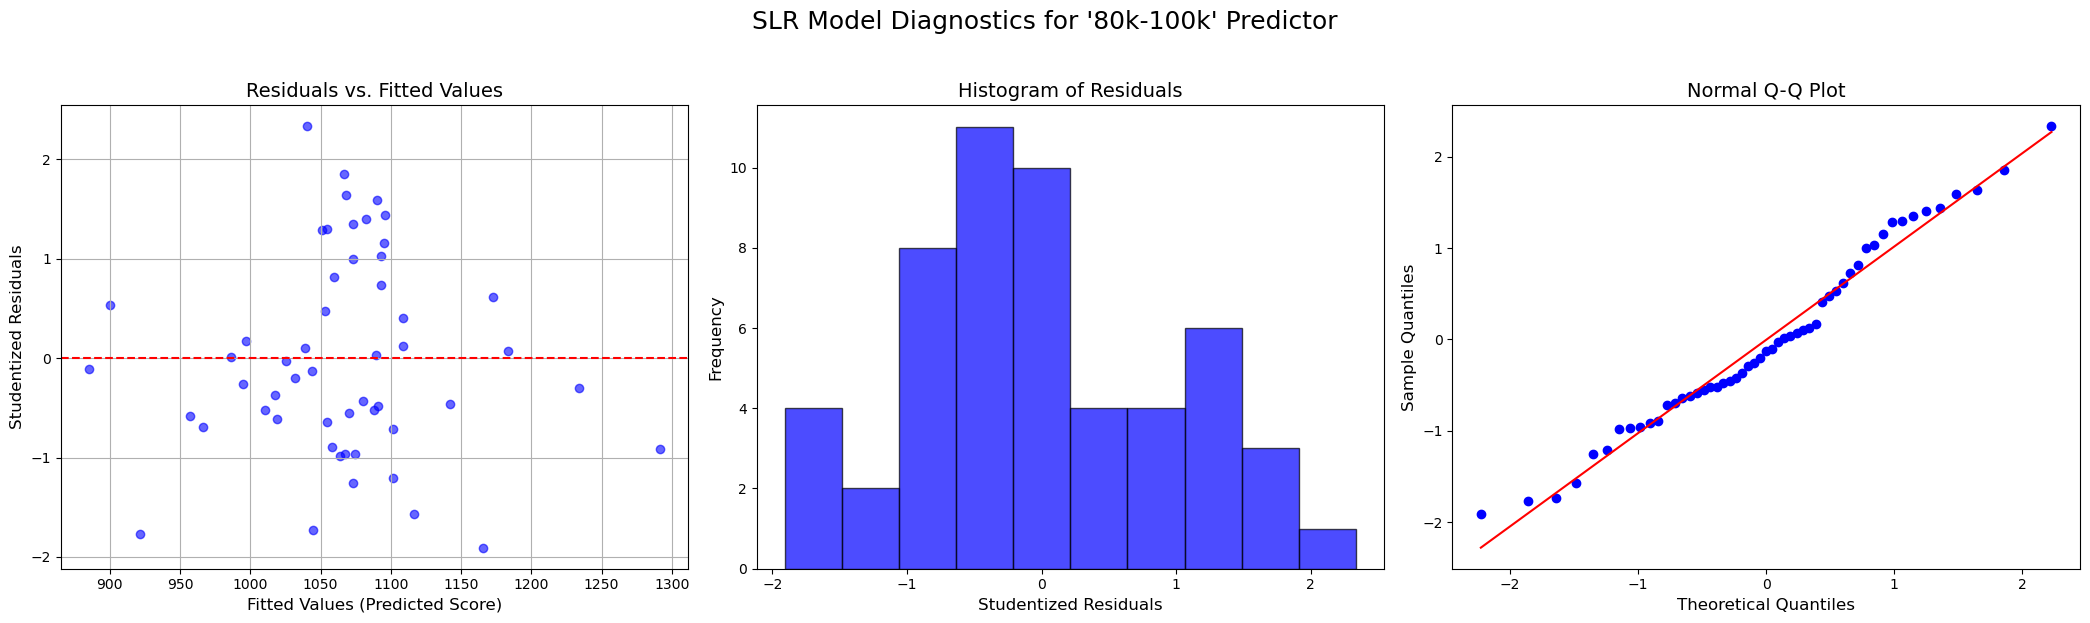

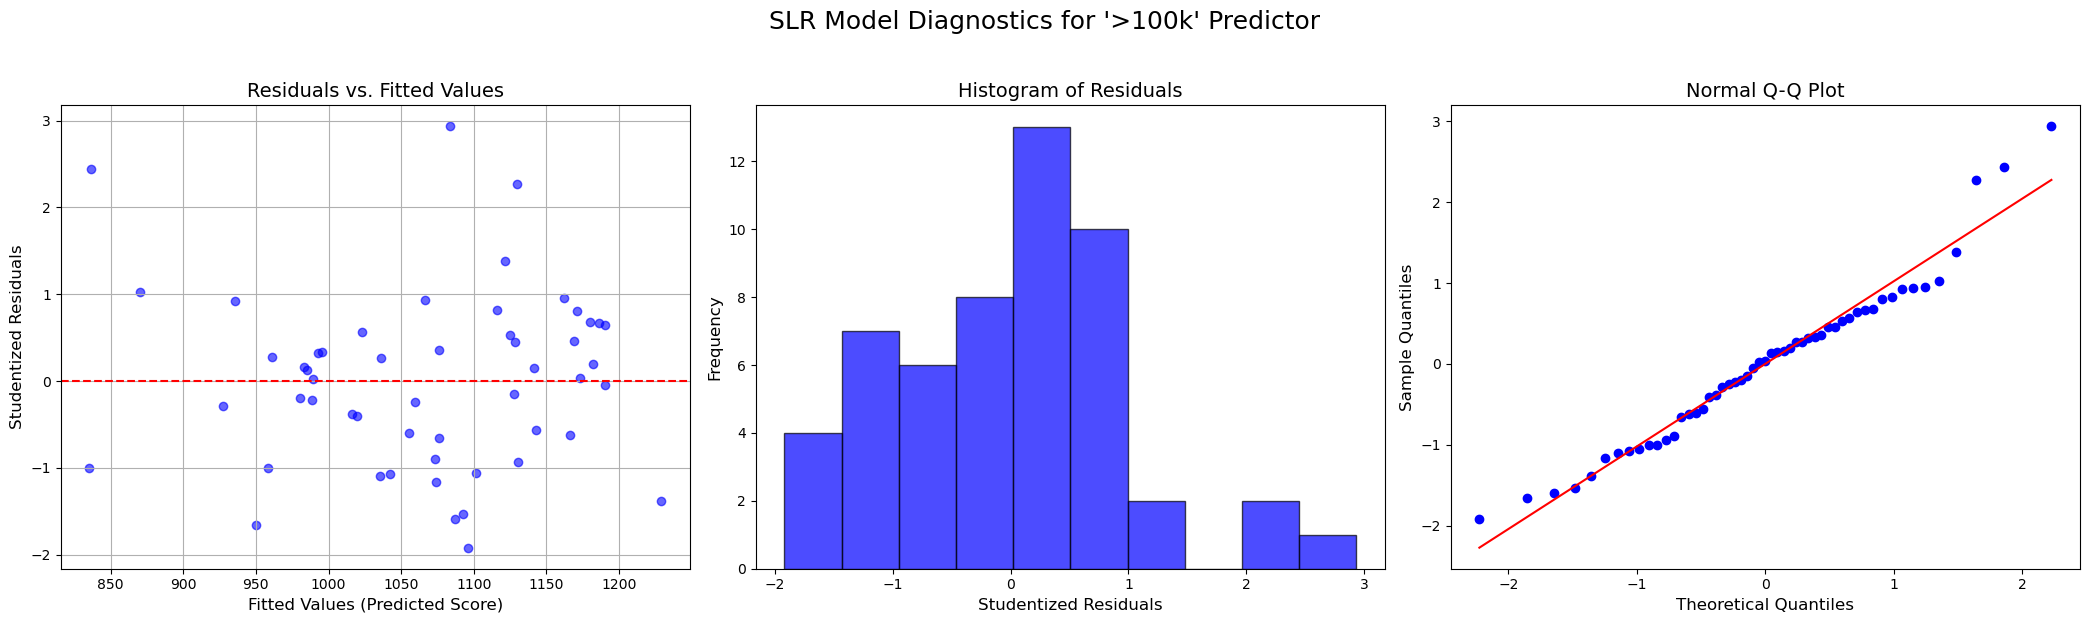

In [52]:
import scipy.stats as stats
for col_name in income_cols_clean:
    
    X = income_df[[col_name]]
    y = scores

    lm = LinearRegression().fit(X, y)
    y_pred = lm.predict(X)

    residuals = y - y_pred
    n = len(y)
    p = X.shape[1] + 1
    
    mse = numpy.sum(residuals**2) / (n - p)

    x_mean = numpy.mean(X.values)
    leverage = (1/n) + ((X.values - x_mean)**2) / numpy.sum((X.values - x_mean)**2)
    
    studentized_residuals = residuals / numpy.sqrt(mse * (1 - leverage.squeeze()))

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    axes[0].scatter(y_pred, studentized_residuals, alpha=0.6, color='blue')
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_title("Residuals vs. Fitted Values", fontsize=14)
    axes[0].set_xlabel("Fitted Values (Predicted Score)", fontsize=12)
    axes[0].set_ylabel("Studentized Residuals", fontsize=12)
    axes[0].grid(True)

    axes[1].hist(studentized_residuals, bins=10, edgecolor='black', alpha=0.7, color='blue')
    axes[1].set_title("Histogram of Residuals", fontsize=14)
    axes[1].set_xlabel("Studentized Residuals", fontsize=12)
    axes[1].set_ylabel("Frequency", fontsize=12)

    stats.probplot(studentized_residuals, dist="norm", plot=axes[2])
    axes[2].set_title("Normal Q-Q Plot", fontsize=14)
    axes[2].set_xlabel("Theoretical Quantiles", fontsize=12)
    axes[2].set_ylabel("Sample Quantiles", fontsize=12)

    fig.suptitle(f"SLR Model Diagnostics for '{col_name}' Predictor", fontsize=18, y=1.03)
    plt.tight_layout()
    plt.show()

In [53]:
from statsmodels.stats.stattools import durbin_watson
for col_name in income_cols_clean:
    
    print(f"\n Model Diagnostics for: '{col_name}'")
    
    X = income_df[[col_name]] 
    y = scores
    lm = LinearRegression().fit(X, y)
    y_pred = lm.predict(X)
    residuals = y - y_pred

    print("Shapiro-Wilk test for normality:")
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("residuals appear to be normally distributed (p > 0.05)")
    else:
        print("residuals do not appear to be normally distributed (p <= 0.05).")

    print("Levene's test for homoscedasticity:")
    fitted_bins = pandas.qcut(y_pred, 3, labels=['Low', 'Mid', 'High'])    
    group1 = residuals[fitted_bins == 'Low']
    group2 = residuals[fitted_bins == 'Mid']
    group3 = residuals[fitted_bins == 'High']
    levene_stat, levene_p = stats.levene(group1, group2, group3)
    print(f"   Statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")
    if levene_p > 0.05:
        print("residuals appear to have equal variance (p > 0.05).")
    else:
        print("residuals do not appear to have equal variance (p <= 0.05).")
            
    #looking for value of dw-stat close to 2
    print("durbin-watson Test for autocorrelation:")
    dw_stat = durbin_watson(residuals)
    print(f"   Statistic: {dw_stat:.4f}")
    if 1.5 < dw_stat < 2.5:
        print("no significant autocorrelation detected, we can assume independence.")
    else:
        print("potential autocorrelation detected, violates independence assumption")
        



 Model Diagnostics for: '<20k'
Shapiro-Wilk test for normality:
   Statistic: 0.9476, p-value: 0.0213
residuals do not appear to be normally distributed (p <= 0.05).
Levene's test for homoscedasticity:
   Statistic: 0.8404, p-value: 0.4375
residuals appear to have equal variance (p > 0.05).
durbin-watson Test for autocorrelation:
   Statistic: 1.5668
no significant autocorrelation detected, we can assume independence.

 Model Diagnostics for: '20k-40k'
Shapiro-Wilk test for normality:
   Statistic: 0.9455, p-value: 0.0174
residuals do not appear to be normally distributed (p <= 0.05).
Levene's test for homoscedasticity:
   Statistic: 1.3679, p-value: 0.2640
residuals appear to have equal variance (p > 0.05).
durbin-watson Test for autocorrelation:
   Statistic: 1.2275
potential autocorrelation detected, violates independence assumption

 Model Diagnostics for: '40k-60k'
Shapiro-Wilk test for normality:
   Statistic: 0.9523, p-value: 0.0338
residuals do not appear to be normally distri

The diagnostic plots and assumption tests show violations, but these results are not that helpful individually. We will conduct these tests for the models with multiple predictors.

Based on the previous results showing potential significance for the lowest two brackets and highest two brackets, we begin to compare some models, using 5 predictors (least significant as a baseline), and the 4 edge brackets. 

Model with 5 predictors
R-squared: 0.8798
Correlation (Actual vs. Predicted): 0.9380
BIC: 402.6636

Model with 4 predictors
R-squared: 0.8633
Correlation (Actual vs. Predicted): 0.9291
BIC: 405.5052


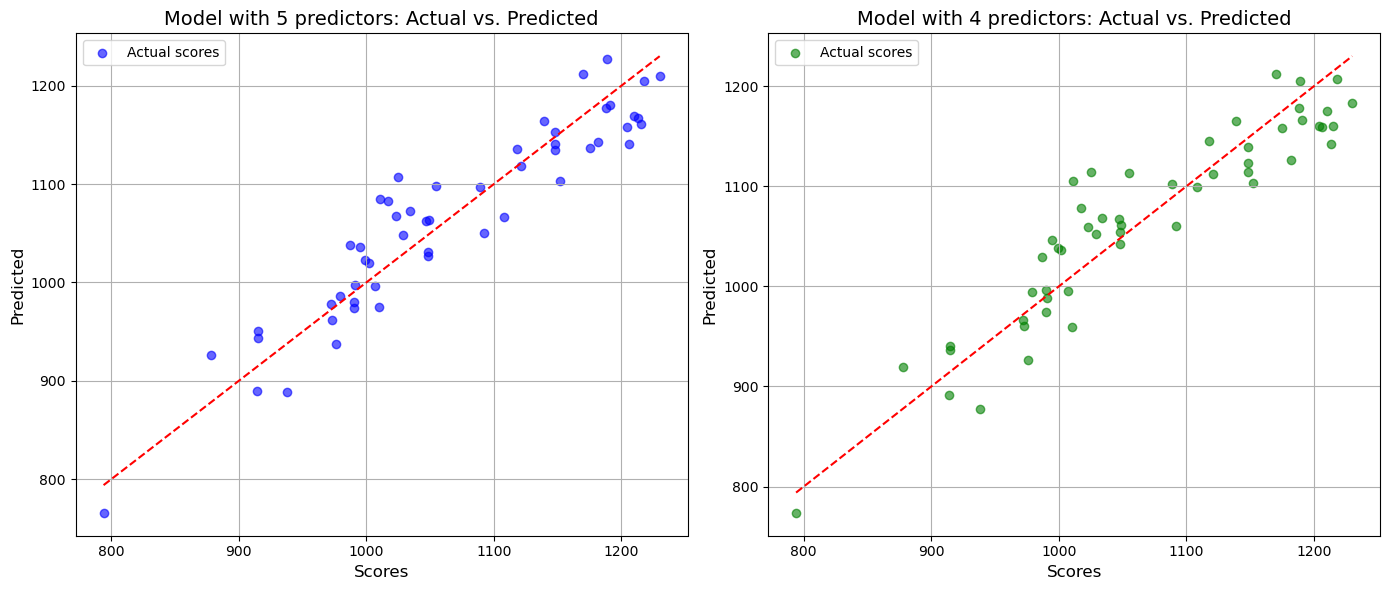

In [56]:
y = scores
cols_5 = ['<20k', '20k-40k', '60k-80k', '80k-100k', '>100k']
cols_4 = ['<20k', '20k-40k', '80k-100k', '>100k']
X_5cols = income_df[cols_5]
X_4cols = income_df[cols_4]

lm5 = LinearRegression().fit(X_5cols, y)
y_pred_5 = lm5.predict(X_5cols)

r_squared_5 = lm5.score(X_5cols, y)
corr_5 = numpy.sqrt(r_squared_5) 

n = len(y)
k_5 = len(cols_5) + 1
residuals_5 = y - y_pred_5
rss_5 = numpy.sum(residuals_5**2)
bic_5 = n * numpy.log(rss_5 / n) + k_5 * numpy.log(n)

lm4 = LinearRegression().fit(X_4cols, y)
y_pred_4 = lm4.predict(X_4cols)

r_squared_4 = lm4.score(X_4cols, y)
corr_4 = numpy.sqrt(r_squared_4)

k_4 = len(cols_4) + 1
residuals_4 = y - y_pred_4
rss_4 = numpy.sum(residuals_4**2)
bic_4 = n * numpy.log(rss_4 / n) + k_4 * numpy.log(n)

print("Model with 5 predictors")
print(f"R-squared: {r_squared_5:.4f}")
print(f"Correlation (Actual vs. Predicted): {corr_5:.4f}")
print(f"BIC: {bic_5:.4f}")
print("\nModel with 4 predictors")
print(f"R-squared: {r_squared_4:.4f}")
print(f"Correlation (Actual vs. Predicted): {corr_4:.4f}")
print(f"BIC: {bic_4:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y, y_pred_5, color='blue', alpha=0.6, label='Actual scores')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_title("Model with 5 predictors: Actual vs. Predicted", fontsize=14)
axes[0].set_xlabel("Scores", fontsize=12)
axes[0].set_ylabel("Predicted", fontsize=12)
axes[0].legend()
axes[0].grid(True)


axes[1].scatter(y, y_pred_4, color='green', alpha=0.6, label='Actual scores')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_title("Model with 4 predictors: Actual vs. Predicted", fontsize=14)
axes[1].set_xlabel("Scores", fontsize=12)
axes[1].set_ylabel("Predicted", fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The models both get high R^2 and correlation values, it seems they both do a good job of explaining variation in SAT scores. The R^2 is slighty higher for the more complex model, and the BIC value is lower. This is significant as BIC punishes more complex models by balancing goodness of fit and model simplicity, but here it shows that the more complex model is still better. This means that 60k-80k income bracket provides value in the model even though it looked weak when analyzing individually.

In [58]:
def plot_regression_diagnostics(X, y, model_name):
    
    lm = LinearRegression().fit(X, y)
    y_pred = lm.predict(X)
    residuals = y - y_pred
    std_residuals = (residuals - residuals.mean()) / residuals.std()
    
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    axes[0].scatter(y_pred, std_residuals, alpha=0.6, color='blue')
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_title("Residuals vs. Fitted Values", fontsize=14)
    axes[0].set_xlabel("Fitted Values", fontsize=12)
    axes[0].set_ylabel("Standardized Residuals", fontsize=12) # Label changed
    axes[0].grid(True)

    axes[1].hist(std_residuals, bins=10, edgecolor='black', alpha=0.7, color='blue')
    axes[1].set_title("Histogram of Residuals", fontsize=14)
    axes[1].set_xlabel("Standardized Residuals", fontsize=12)
    axes[1].set_ylabel("Frequency", fontsize=12)
    axes[1].grid(True)
    
    stats.probplot(std_residuals, dist="norm", plot=axes[2])
    axes[2].set_title("Normal Q-Q Plot", fontsize=14)
    axes[2].set_xlabel("Theoretical Quantiles", fontsize=12)
    axes[2].set_ylabel("Sample Quantiles", fontsize=12)

    fig.suptitle(f"MLR Model Diagnostics for '{model_name}'", fontsize=18, y=1.03)
    plt.tight_layout()
    plt.show()

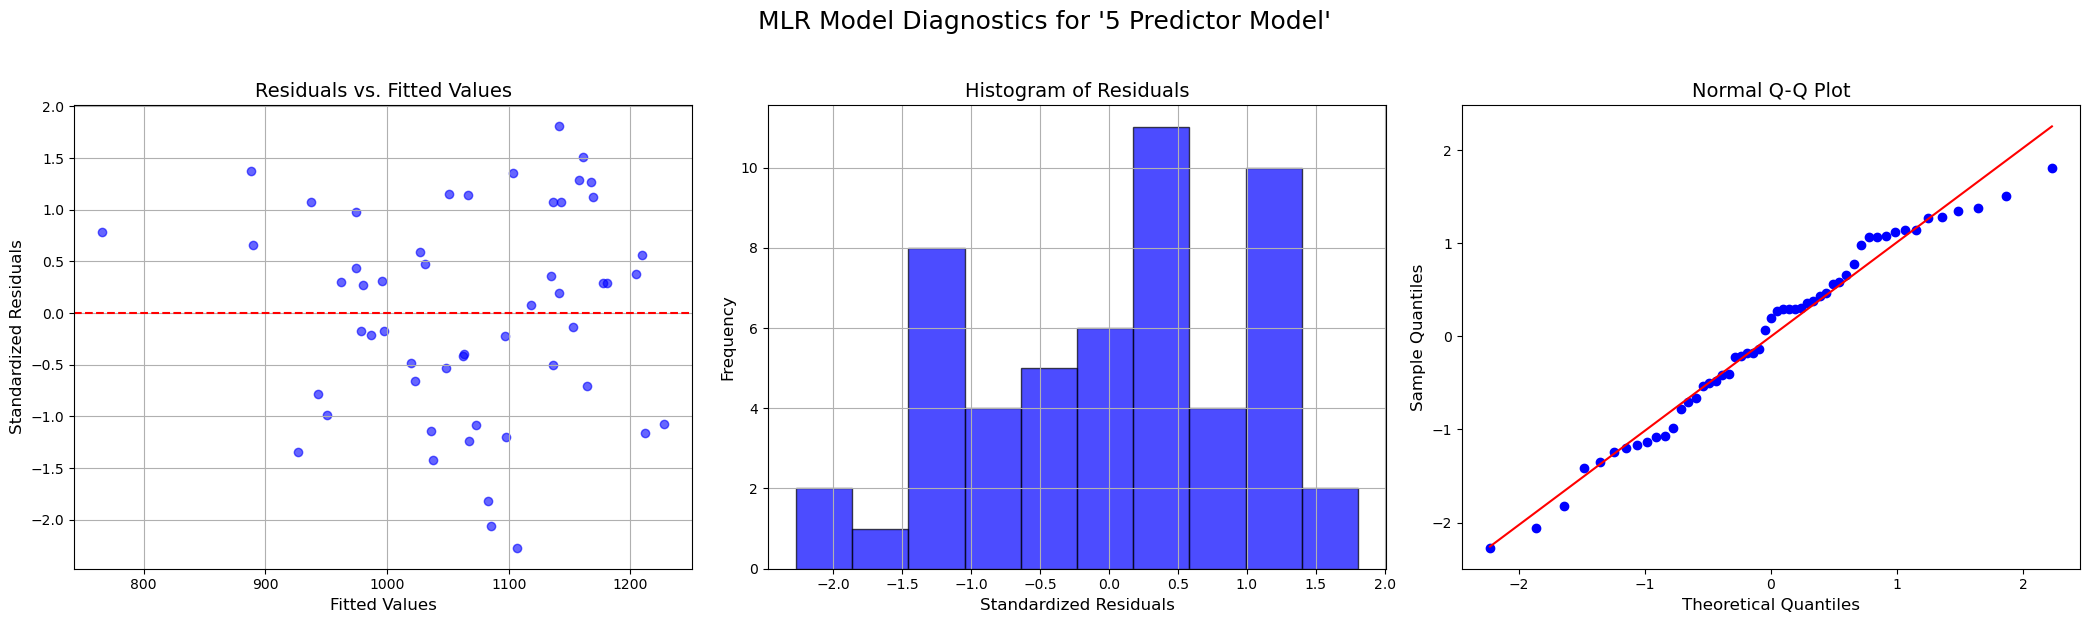

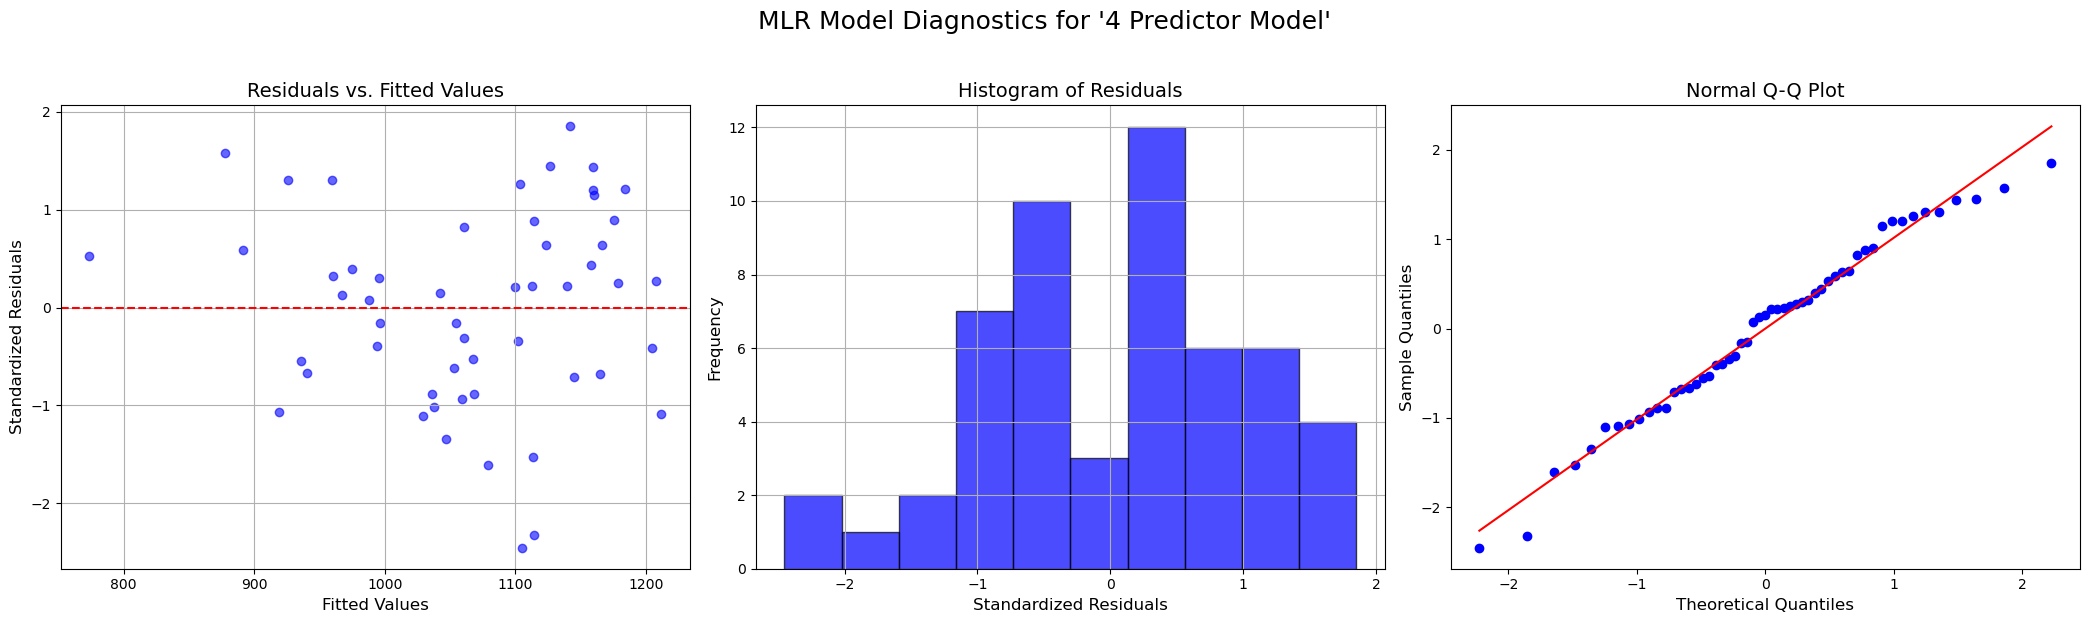

In [59]:
plot_regression_diagnostics(X_5cols, y, "5 Predictor Model")
plot_regression_diagnostics(X_4cols, y, "4 Predictor Model")

In [60]:
def run_diagnostic_tests(X_model, y_target, model_name):
    
    print(f"\n Model Diagnostics for: '{model_name}'")
    
    lm = LinearRegression().fit(X_model, y_target)
    y_pred = lm.predict(X_model)
    residuals = y_target - y_pred

    print("\nShapiro-Wilk test for normality:")
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("residuals appear to be normally distributed (p > 0.05).")
    else:
        print("residuals do not appear to be normally distributed (p <= 0.05).")

    print("\nLevene's test for homoscedasticity:")
    fitted_bins = pandas.qcut(y_pred, 3, labels=['Low', 'Mid', 'High'], duplicates='drop')
    groups = [residuals[fitted_bins == label] for label in fitted_bins.categories]
    levene_stat, levene_p = stats.levene(*groups)
    
    print(f"   Statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")
    if levene_p > 0.05:
        print("residuals appear to have equal variance (p > 0.05).")
    else:
        print("residuals do not appear to have equal variance (p <= 0.05).")


    print("\nDurbin-watson Test for autocorrelation:")
    dw_stat = durbin_watson(residuals)
    print(f"   Statistic: {dw_stat:.4f}")
    if 1.5 < dw_stat < 2.5:
        print("no significant autocorrelation detected, we can assume independence.")
    else:
        print("potential autocorrelation detected, violates independence assumption")

In [61]:
run_diagnostic_tests(X_5cols, y, "5 Predictor Model")
run_diagnostic_tests(X_4cols, y, "4 Predictor Model")


 Model Diagnostics for: '5 Predictor Model'

Shapiro-Wilk test for normality:
   Statistic: 0.9717, p-value: 0.2387
residuals appear to be normally distributed (p > 0.05).

Levene's test for homoscedasticity:
   Statistic: 1.3533, p-value: 0.2677
residuals appear to have equal variance (p > 0.05).

Durbin-watson Test for autocorrelation:
   Statistic: 1.7954
no significant autocorrelation detected, we can assume independence.

 Model Diagnostics for: '4 Predictor Model'

Shapiro-Wilk test for normality:
   Statistic: 0.9787, p-value: 0.4577
residuals appear to be normally distributed (p > 0.05).

Levene's test for homoscedasticity:
   Statistic: 0.3583, p-value: 0.7007
residuals appear to have equal variance (p > 0.05).

Durbin-watson Test for autocorrelation:
   Statistic: 1.7771
no significant autocorrelation detected, we can assume independence.


Both 4 and 5 predictor models meet all assumptions, so based on our model and assumptions evaluation, our best model choice for the income brackets is the 5 predictor model that includes the <20k, 20k-40k, 60k-80k, 80k-100k, >100k income brackets. 

Average Overall GPA Level - Hannah 

In [64]:
# GPA predictor columns (number of test takers per GPA category)
gpa_cols = [
    'GPA.A plus.Test-takers', 'GPA.A.Test-takers', 'GPA.A minus.Test-takers',
    'GPA.B.Test-takers', 'GPA.C.Test-takers',
    'GPA.D or lower.Test-takers', 'GPA.No response.Test-takers'
]

scores = combined_sat_2014['Total_Overall_Score']


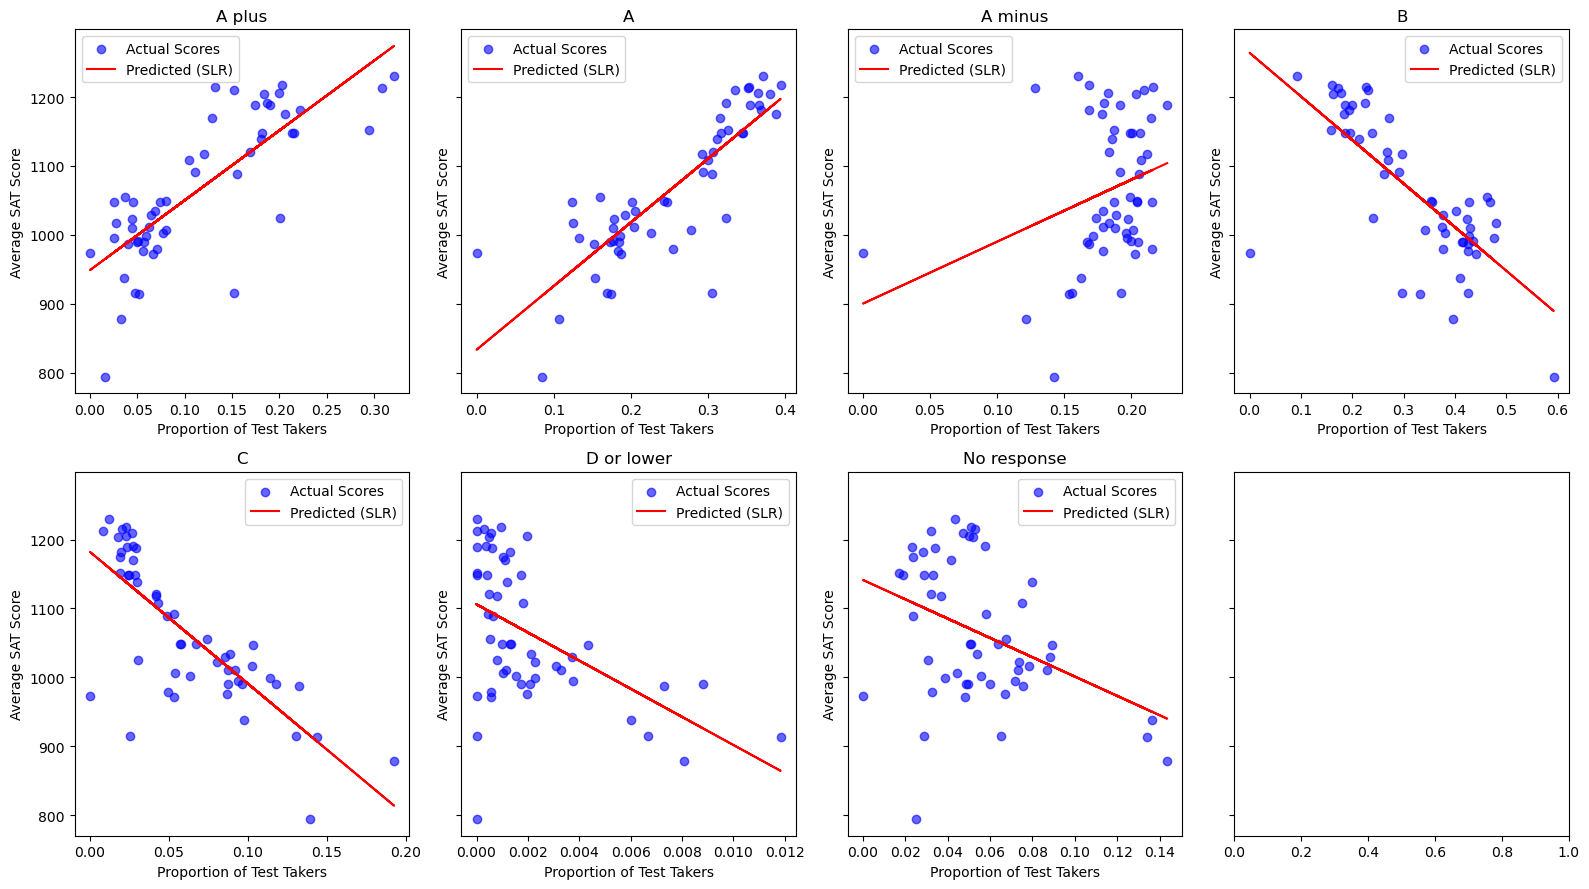

,GPA Bracket,R_squared,Correlation
0,GPA.A plus,0.622728,0.789131
1,GPA.A,0.699576,0.836406
2,GPA.A minus,0.085776,0.292876
3,GPA.B,0.544863,-0.738149
4,GPA.C,0.608900,-0.780320
5,GPA.D or lower,0.246486,-0.496474
6,GPA.No response,0.153028,-0.391188


In [65]:
metrics = []
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharey=True)
axes = axes.ravel()

for i, col in enumerate(gpa_cols):
    X = combined_sat_2014[[col]]
    y = scores
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)

    r2 = model.score(X, y)
    corr = numpy.corrcoef(combined_sat_2014[col], y)[0, 1]
    metrics.append({'GPA Bracket': col.replace('.Test-takers', ''), 'R_squared': r2, 'Correlation': corr})

    axes[i].scatter(X, y, color='blue', alpha=0.6, label='Actual Scores')
    axes[i].plot(X, y_pred, color='red', label='Predicted (SLR)')
    axes[i].set_title(f"{col.replace('GPA.', '').replace('.Test-takers','')}", fontsize=12)
    axes[i].set_xlabel("Proportion of Test Takers")
    axes[i].set_ylabel("Average SAT Score")
    axes[i].legend()

plt.tight_layout()
plt.show()

metrics_df = pandas.DataFrame(metrics)
metrics_df



Interpretation – Average GPA Predictors (Hannah)
The relationship between GPA level and SAT score shows a clear positive trend — as the proportion of test takers reporting higher GPAs increases, average SAT scores also rise.
The strongest predictors are likely in the upper GPA brackets (A+, A, A–), while lower GPA groups (C, D or lower) show weaker or negative correlations.
The “No Response” category may display an outlier trend or lower correlation, suggesting missing or uncertain data from that subgroup.
These results indicate that GPA distribution among test takers is a strong indicator of school-wide SAT performance, consistent with expectations of academic self-selection.

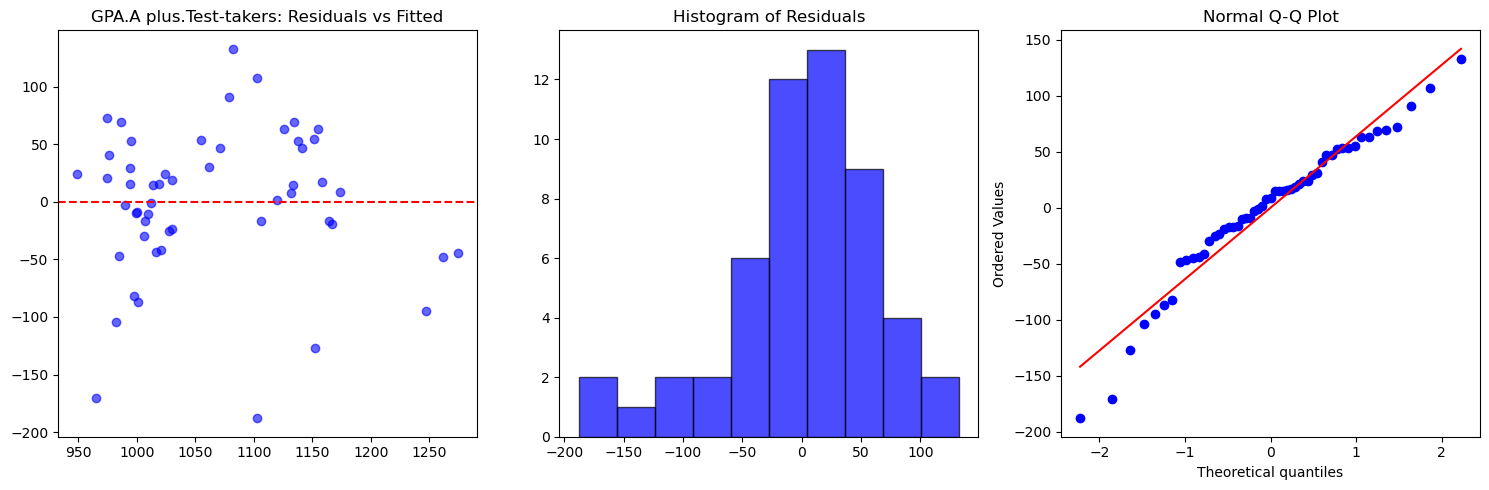

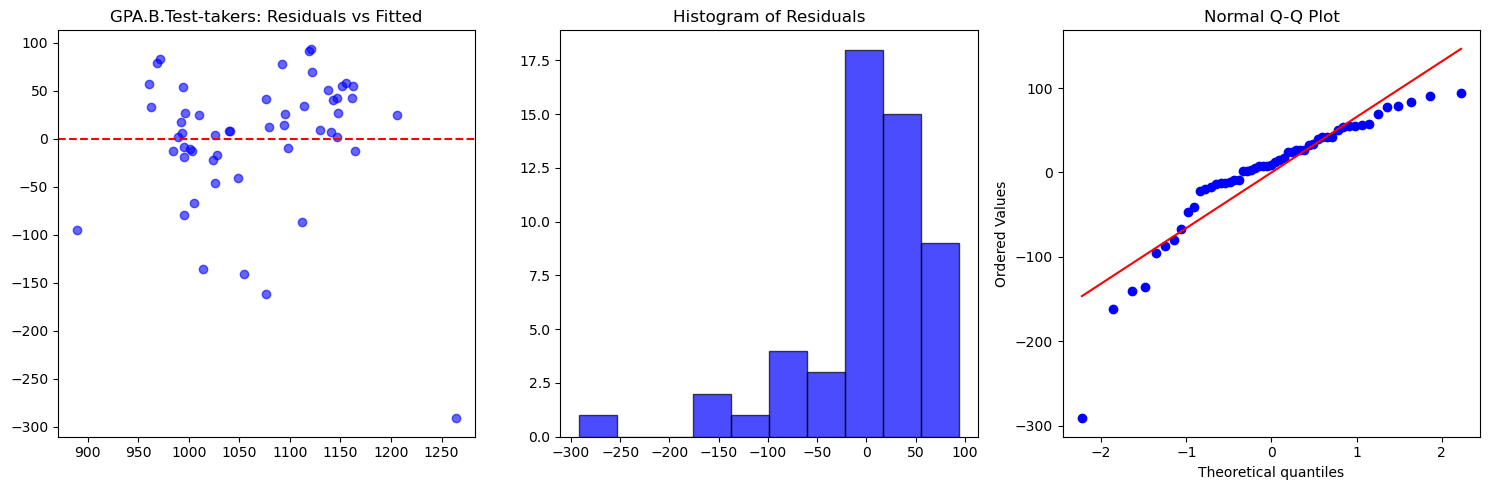

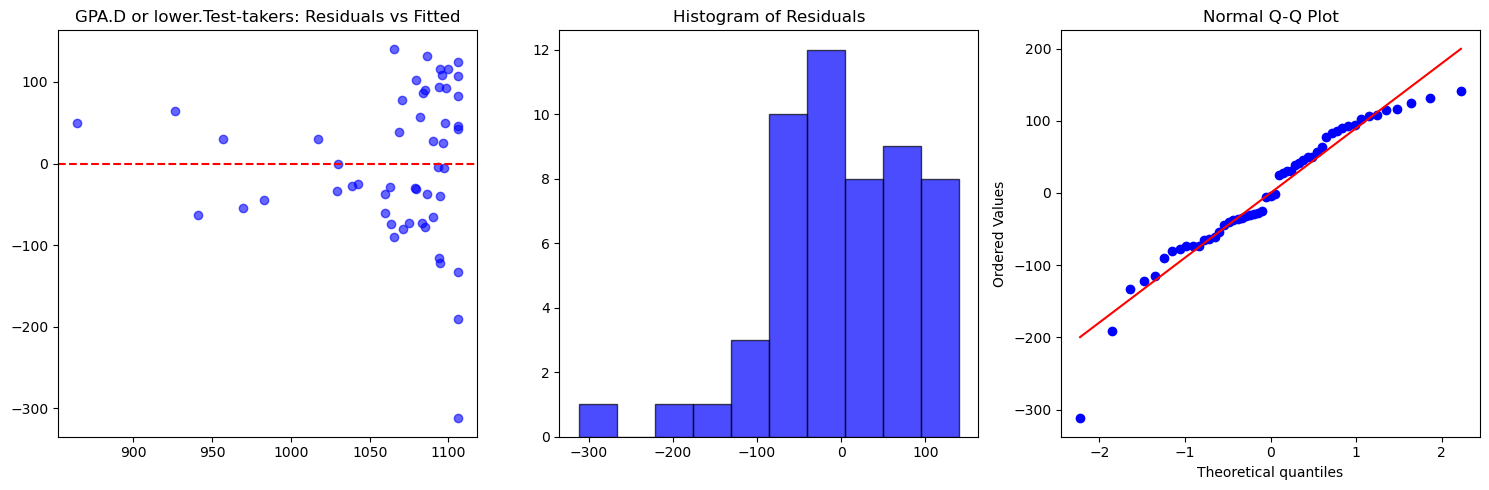

In [67]:
for col in ['GPA.A plus.Test-takers', 'GPA.B.Test-takers', 'GPA.D or lower.Test-takers']:
    X = combined_sat_2014[[col]]
    y = scores
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Residuals vs Fitted
    axes[0].scatter(y_pred, residuals, alpha=0.6, color='blue')
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_title(f"{col}: Residuals vs Fitted")
    
    # Histogram
    axes[1].hist(residuals, bins=10, color='blue', edgecolor='black', alpha=0.7)
    axes[1].set_title("Histogram of Residuals")
    
    # Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title("Normal Q-Q Plot")
    
    plt.tight_layout()
    plt.show()



In [68]:
for col in ['GPA.A plus.Test-takers', 'GPA.B.Test-takers', 'GPA.D or lower.Test-takers']:
    print(f"\nModel Diagnostics for: {col}")
    
    X = combined_sat_2014[[col]]
    y = scores
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # Normality
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
    
    # Homoscedasticity
    fitted_bins = pandas.qcut(y_pred, q=3, labels=['Low', 'Mid', 'High'])
    group_res = [residuals[fitted_bins == lvl] for lvl in ['Low', 'Mid', 'High']]
    lev_stat, lev_p = stats.levene(*group_res)
    print(f"Levene’s p-value: {lev_p:.4f}")
    
    # Independence
    dw = durbin_watson(residuals)
    print(f"Durbin-Watson: {dw:.4f}")




Model Diagnostics for: GPA.A plus.Test-takers
Shapiro-Wilk p-value: 0.0456
Levene’s p-value: 0.8580
Durbin-Watson: 2.1088

Model Diagnostics for: GPA.B.Test-takers
Shapiro-Wilk p-value: 0.0000
Levene’s p-value: 0.7987
Durbin-Watson: 1.8957

Model Diagnostics for: GPA.D or lower.Test-takers
Shapiro-Wilk p-value: 0.0167
Levene’s p-value: 0.0612
Durbin-Watson: 1.6389


In [69]:
metrics_df.sort_values(by='Correlation', ascending=False)


,GPA Bracket,R_squared,Correlation
1,GPA.A,0.699576,0.836406
0,GPA.A plus,0.622728,0.789131
2,GPA.A minus,0.085776,0.292876
6,GPA.No response,0.153028,-0.391188
5,GPA.D or lower,0.246486,-0.496474
3,GPA.B,0.544863,-0.738149
4,GPA.C,0.608900,-0.780320


In [70]:
cols_5 = [
    'GPA.D or lower.Test-takers',
    'GPA.A plus.Test-takers',
    'GPA.No response.Test-takers',
    'GPA.A.Test-takers',
    'GPA.A minus.Test-takers'
]

cols_4 = [
    'GPA.D or lower.Test-takers',
    'GPA.A plus.Test-takers',
    'GPA.No response.Test-takers',
    'GPA.A.Test-takers'
]

y = combined_sat_2014['Total_Overall_Score']

def fit_model(cols):
    X = combined_sat_2014[cols]
    lm = LinearRegression().fit(X, y)
    y_pred = lm.predict(X)
    r2 = lm.score(X, y)
    corr = numpy.corrcoef(y, y_pred)[0, 1]
    n, k = len(y), len(cols)
    rss = numpy.sum((y - y_pred)**2)
    bic = n * numpy.log(rss / n) + k * numpy.log(n)
    return r2, corr, bic, y_pred

r2_5, corr_5, bic_5, y_pred5 = fit_model(cols_5)
r2_4, corr_4, bic_4, y_pred4 = fit_model(cols_4)

print("Model with 5 predictors")
print(f"R²: {r2_5:.4f}, Corr: {corr_5:.4f}, BIC: {bic_5:.2f}")
print("\nModel with 4 predictors")
print(f"R²: {r2_4:.4f}, Corr: {corr_4:.4f}, BIC: {bic_4:.2f}")



Model with 5 predictors
R²: 0.7295, Corr: 0.8541, BIC: 441.68

Model with 4 predictors
R²: 0.7268, Corr: 0.8525, BIC: 438.24


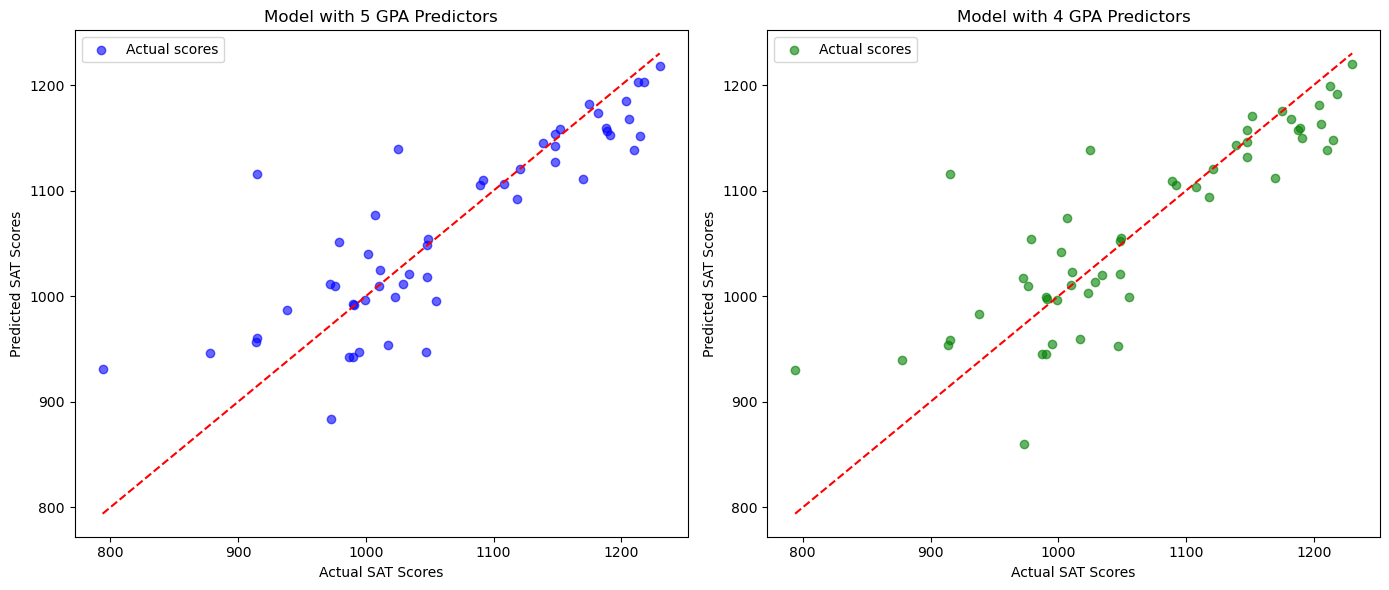

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y, y_pred5, color='blue', alpha=0.6, label='Actual scores')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_title('Model with 5 GPA Predictors')
axes[0].set_xlabel('Actual SAT Scores')
axes[0].set_ylabel('Predicted SAT Scores')
axes[0].legend()

axes[1].scatter(y, y_pred4, color='green', alpha=0.6, label='Actual scores')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_title('Model with 4 GPA Predictors')
axes[1].set_xlabel('Actual SAT Scores')
axes[1].set_ylabel('Predicted SAT Scores')
axes[1].legend()

plt.tight_layout()
plt.show()


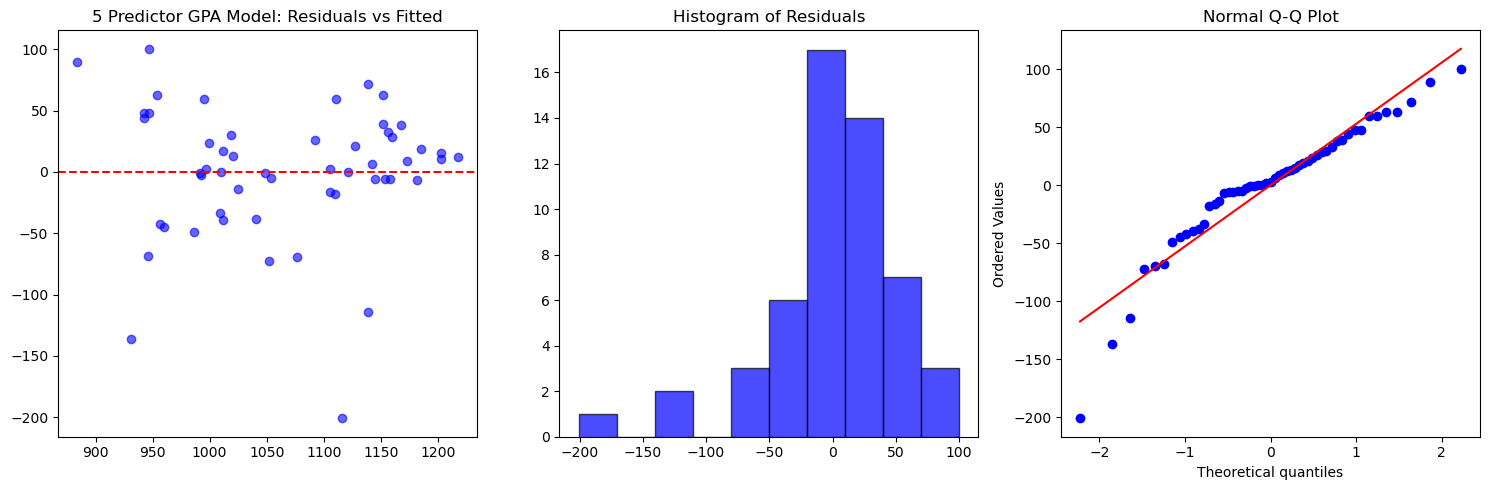

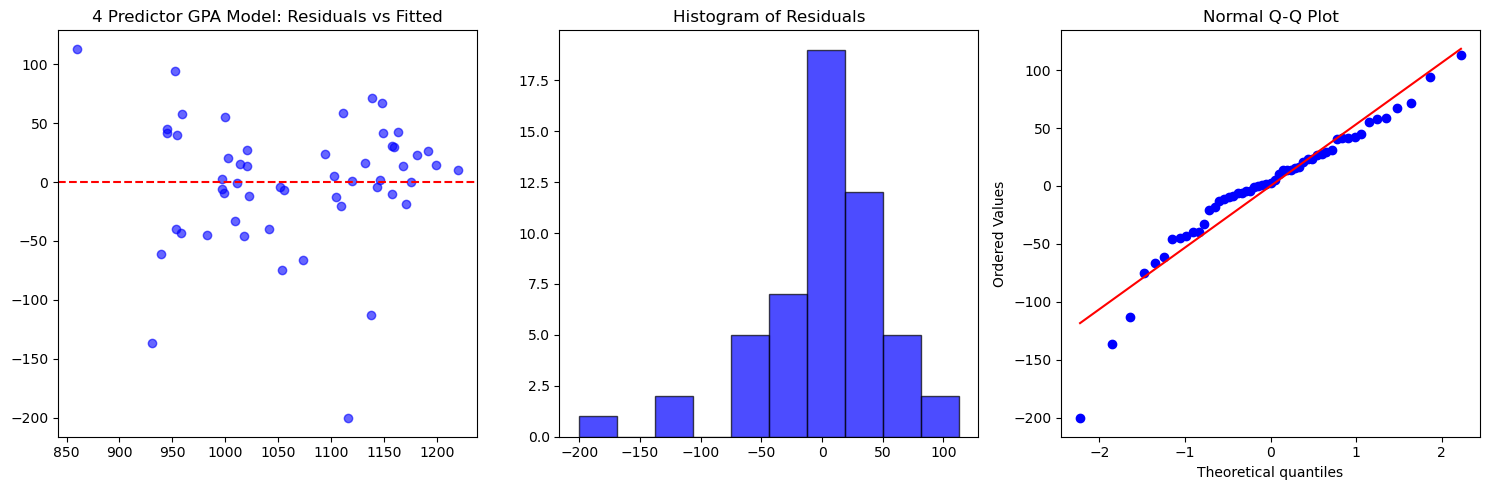

In [72]:
def regression_diagnostics(X, y, model_name):
    lm = LinearRegression().fit(X, y)
    y_pred = lm.predict(X)
    residuals = y - y_pred
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].scatter(y_pred, residuals, alpha=0.6, color='blue')
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_title(f"{model_name}: Residuals vs Fitted")

    axes[1].hist(residuals, bins=10, color='blue', edgecolor='black', alpha=0.7)
    axes[1].set_title("Histogram of Residuals")

    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title("Normal Q-Q Plot")

    plt.tight_layout()
    plt.show()

regression_diagnostics(combined_sat_2014[cols_5], y, "5 Predictor GPA Model")
regression_diagnostics(combined_sat_2014[cols_4], y, "4 Predictor GPA Model")


Both GPA-based models show strong explanatory power, with negative correlations indicating that states with more low-GPA students tend to have lower average SAT scores.
The 5-predictor model provides slightly better fit and lower BIC, meaning it balances model complexity with accuracy.
Diagnostic plots and tests suggest the model meets linear regression assumptions.
Overall, GPA distributions are statistically significant predictors of SAT outcomes and add valuable explanatory power alongside the group’s socioeconomic variables.

Kathleen's work starts again here

**Final Model**

Now that we've done analysis on the individual variables, can we combine many predictors from different categories into one big model? In particular, since predictors in the same category were able to be combined in small linear regression models, can combine those models into a larger model?


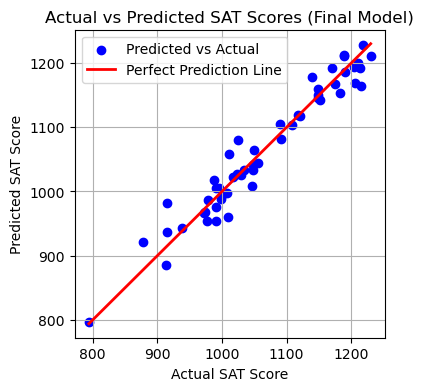

R squared:  0.9447008651162765
Correlation:  0.9719572342013184


In [75]:
final_y = combined_sat_2014["Total_Overall_Score"]

final_x = combined_sat_2014[["Academic Subjects.Arts/Music.Average GPA",
                             "Academic Subjects.English.Average GPA",
                             "Academic Subjects.Foreign Languages.Average GPA",
                             "Academic Subjects.Mathematics.Average GPA",
                             "Academic Subjects.Natural Sciences.Average GPA",
                             "Academic Subjects.Social Sciences/History.Average GPA",
		                     "Academic Subjects.Arts/Music.Average Years", 
                             "Academic Subjects.English.Average Years", 
                             "Academic Subjects.Mathematics.Average Years", 
                             "Academic Subjects.Natural Sciences.Average Years",
                             "Family Income.Less than 20k.Test-takers", 
                             "Family Income.Between 20-40k.Test-takers", 
                             "Family Income.Between 60-80k.Test-takers", 
                             "Family Income.Between 80-100k.Test-takers", 
                             "Family Income.More than 100k.Test-takers",
                             'GPA.D or lower.Test-takers',
                             'GPA.A plus.Test-takers',
                             'GPA.No response.Test-takers',
                             'GPA.A.Test-takers',
                             'GPA.A minus.Test-takers']]

final_model = LinearRegression().fit(final_x, final_y)
final_y_pred = final_model.predict(final_x)

final_y_arr    = numpy.asarray(final_y).ravel()          # actual
final_yhat_arr = numpy.asarray(final_y_pred).ravel()     # predicted from all_lm

# Scatter + 45° perfect-fit line
plt.figure(figsize=(4, 4))
plt.scatter(final_y_arr, final_yhat_arr, color="blue", label="Predicted vs Actual")
lo, hi = final_y_arr.min(), final_y_arr.max()
plt.plot([lo, hi], [lo, hi], color="red", linewidth=2, label="Perfect Prediction Line")
plt.xlabel("Actual SAT Score")
plt.ylabel("Predicted SAT Score")
plt.title("Actual vs Predicted SAT Scores (Final Model)")
plt.legend()
plt.grid(True)
plt.show()

r2 = final_model.score(final_x, final_y)
corr = numpy.corrcoef(final_y, final_y_pred)[0, 1]

print("R squared: ", r2)
print("Correlation: ", corr)



**Conclusions**

The best predictors of the average SAT score by state in 2014 were:
- The average GPA in Art/Music
- The average GPA in English
- The average GPA in Foreign Languages
- The average GPA in Natural Sciences
- The average GPA in Social Sciences/History
- The average number of years spent in Art/Music classes
- The average number of years spent in English classes
- The average number of years spent in Mathematics classes
- The average number of years spent in Natural Science classes
- The proportion of test takers with a family income of less than 20K per year
- The proportion of test takers with a family income betweeen 20K and 40K per year
- The proportion of test takers with a family income betweeen 40K and 60K per year
- The proportion of test takers with a family income betweeen 60K and 80K per year
- The proportion of test takers with a family income betweeen 80K and 100K per year
- The proportion of test takers with a family income of more than 100K year
- The proportion of test takers with an A+ average GPA
- The proportion of test takers with an A average GPA
- The proportion of test takers with an A- average GPA
- The proportion of test takers with a D or lower average GPA
- The proportion of test takers who didn't give a response for the average GPA

The multiple linear regression model with all these predictors as inputs was highly predictive, with a correlation of about 0.97 and an R squared value of about 0.94, indicating that the model explains about 94% of the variance in average SAT scores from 2014 - more than any of the individual predictors or smaller multi-linear regression models. This in turn shows that no one class of predictor can solely predict SAT scores, although there are some classes of predictors that can contribute more than others. For example, the proportions of test takers at all income brackets contributed to this model, while only some proportions of test takers at different GPA levels contribute. 

Some of the final predictor variables were more surprising than others. For example, income isn't that surprising, as families with higher yearly incomes are able to spend more money on prep programs and tutors. Also, since taking the SAT costs money, weathier families are probably also more likely to be able to pay for their kids to take the SAT multiple times to increase their scores, contributing to a raised average. Since the SAT primarily tests on English and Math, it's also not surprising that more years of instruction in those subjects contributes to higher SAT scores. However, the inclusion of the proportion of students with no response to the average overall GPA is surprising; perhaps students with lower GPAs were more likely to not give a response, explaining its inclusion along with the proportion of test takers with a D or lower average GPA.

There are also some surprising exclusions. I was surprised that the student-teacher ratio provided almost no predictive value, given that's something schools often like to show off as an indicator of education quality. Perhaps if we were able to get the average student to teacher ratio for only high school level grades, it would have been more predictive. The exclusion of the average math GPA was also surprising; maybe the math questions on the SAT are so different or more complex than the ones normally given out by math teachers that having a high math GPA isn't enough - you'd need the instinct to recognize different problem types that is better gained by more years of math instruction.

There are a few key limitations on this analysis. First, this data is from 2014, over 10 years ago. It's likely that there are different predictors for average SAT scores in 2025 than there were in 2014; for example, perhaps the how long each state closed schools during the COVID-19 pandemic would serve as a predictor. Second, we constructed the average overall SAT score by adding the average verbal and math scores, but it's possible that the true average SAT scores were a few points off from what we used. Third, it turned out that a lot of our key predictors came from one data set, making it possible that our analysis was heavily subjected to any biases from that data. 

There are several possible further research questions suggested by this data:
* Could we use our model to predict the average SAT scores from 2015?
* Do different states have different predictors? Perhaps we could use k-means clustering to make clusters of states based on test-taker demographics, overall student demographics, or some other criteria, then find the best predictors for each of those clusters.
* Do the verbal and math subscores have different predictors?

***Who did what?***

Kathleen - question; data cleaning; analysis of the average number of full time teachers, average student/teacher ratio, total number of test takers, and test taker breakdown by gender predictors; final overall model; conclusions

Evan - Analysis of the average GPA by subject as predictors

Cheyenne - Analysis of the average number of years by subject as predictors

Ziad - Analysis of the proportions of test takers in each income bracket as predictors

Hannah - Analysus the proportions of test takers at each GPA level as predictors 


******Part 3******

***Define questions***

For our Project Part 2, we searched for the best predictors for state average SAT scores. However, say you were interested in increasing the average SAT score for a particular state. The predictors identified in Part 2 might be somewhat helpful, but it's likely that different states would have different predictors. We could redo what we did in Part 2 for each state, but that would be tedious. What if we could group states based on their educational data?

The US census bureau divides states into geographic regions for the purpose of data analysis (see: https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States#Census_Bureau-designated_regions_and_divisions). It seems logical that we could do something similar, but based solely on educational data. Based on the data, we can use k-means clustering to figure out how to divide the states, and how many regions are best.

**Our Question is: How can the states be divided into regions based on educational data?** 

***Collect Data***

We'll use our SAT data set from Part 2. We also found that the National Center for Educational Statistics (NCES) publishes a lot of demographic data for each school, including full time teacher employment, student race distribution, and free/reduced lunch eligibility. However, the NCES data is only available in CSV format from 2015 onward. Thus, we'll have to switch our year of analysis to the 2015-2016 school year, as opposed to the 2014-2015 school year for Part 2. (NCES website: https://nces.ed.gov/ccd/pubschuniv.asp)

***Process Data***

For the SAT data, we can use the same cleaning techniques as from Part 2, but for the 2015 data:

In [82]:
sat_data_2015 = sat_data.loc[sat_data["Year"] == 2015, :].iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 22, 
                                                                   25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61]].copy()
sat_data_2015["Total_Overall_Score"] = sat_data_2015["Total.Math"] + sat_data_2015["Total.Verbal"]
sat_data_2015 = sat_data_2015.drop(columns = ["Total.Math", "Total.Verbal"])
total_test_takers = sat_data_2015["Total.Test-takers"]
cols = ["Family Income.Between 20-40k.Test-takers", "Family Income.Between 40-60k.Test-takers", "Family Income.Between 60-80k.Test-takers", 
        "Family Income.Between 80-100k.Test-takers", "Family Income.Less than 20k.Test-takers", "Family Income.More than 100k.Test-takers",
        "GPA.A minus.Test-takers", "GPA.A plus.Test-takers", "GPA.A.Test-takers", "GPA.B.Test-takers", "GPA.C.Test-takers", 
        "GPA.D or lower.Test-takers", "GPA.No response.Test-takers", "Gender.Female.Test-takers", "Gender.Male.Test-takers"]
for col in cols:
    sat_data_2015[col] = sat_data_2015[col]/total_test_takers
sat_data_2015 = sat_data_2015.reset_index()
sat_data_2015.head()

,index,Year,State.Code,State.Name,Total.Test-takers,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,...,GPA.A minus.Test-takers,GPA.A plus.Test-takers,GPA.A.Test-takers,GPA.B.Test-takers,GPA.C.Test-takers,GPA.D or lower.Test-takers,GPA.No response.Test-takers,Gender.Female.Test-takers,Gender.Male.Test-takers,Total_Overall_Score
0,524,2015,AL,Alabama,2929,3.94,2.3,3.67,4.0,3.64,...,0.189143,0.182998,0.309662,0.264254,0.031410,0.000000,0.022533,0.572209,0.427791,1088
1,525,2015,AK,Alaska,3799,3.83,2.0,3.49,3.9,3.47,...,0.181627,0.073177,0.213740,0.359832,0.089234,0.003159,0.079231,0.569097,0.430903,1014
2,526,2015,AZ,Arizona,21545,3.87,2.3,3.52,3.9,3.51,...,0.204363,0.079322,0.237642,0.364632,0.063634,0.000743,0.049663,0.557624,0.442376,1052
3,527,2015,AR,Arkansas,1207,3.94,2.5,3.73,4.0,3.74,...,0.211268,0.196355,0.355427,0.195526,0.020713,0.000000,0.020713,0.566694,0.433306,1141
4,528,2015,CA,California,241553,3.79,1.9,3.42,3.9,3.42,...,0.189892,0.043046,0.176591,0.433416,0.087207,0.001221,0.068627,0.551502,0.448498,1003


We'll now switch to cleaning the NCES data. From the NCES page linked above, we grab 3 datasets for the 2015-2016 year: the ones for membership (for getting the race/ethnicity distribution), staff (for getting full-time staff employment), and lunch program eligibility (for getting free-reduced lunch program eligibility). We'll start with membership:

In [84]:
# Read in the data, all as strings due to the weird way the data is encoded
membership_unclean = pandas.read_csv("./data/Membership_1516.csv", dtype=str)
# Select only the State Code and total num of students of each race
membership_unclean = membership_unclean[["STABR", "AM", "AS", "HI", "BL", "WH", "HP", "TR"]]
# Get number columns back to ints
membership_unclean[["AM", "AS", "HI", "BL", "WH", "HP", "TR"]] = membership_unclean[["AM", "AS", "HI", "BL", "WH", "HP", "TR"]].astype(int)
# Replace any negatives with NaN
membership_clean = membership_unclean.replace(-1, numpy.nan).replace(-2, numpy.nan).replace(-9, numpy.nan)
for col in ["AM", "AS", "HI", "BL", "WH", "HP", "TR"]:
    # Replace any NaNs with the mean for the state
    membership_clean[col] = membership_clean[col].fillna(membership_clean.groupby("STABR")[col].transform("mean"))
    # If the state doesn't report in that racial category at all, impute with 0
    # Mainly because NY doesn't break out Hawaiian Native/Pacific Islander as a seperate group
    membership_clean[col] = membership_clean[col].fillna(0)
# Calculate total students per school 
membership_clean["TotalStudents"] = (membership_clean["AM"] + membership_clean["AS"] + membership_clean["HI"] + membership_clean["BL"] 
                                        + membership_clean["WH"] + membership_clean["HP"] + membership_clean["TR"])
# Calculate overall state totals, give columns clearer names
membership_totals = (membership_clean.groupby("STABR").sum()
                  .reset_index()).rename(columns={"STABR": "State.Code","AM": "AmericanIndianAlaskanNative", "AS": "Asian", "HI": "Hispanic",
                                                 "BL": "Black", "WH": "White", "HP": "HawaiianNativePacificIslander", 
                                                  "TR": "TwoOrMoreRaces"})
# Drop data for Bureau of Indian Affairs, Department of Defense, and Guam schools
membership_totals = (membership_totals.drop([4, 9, 13])).reset_index(drop = True)
# Convert to get relative racial/ethnic distribution for each state
for col in ["AmericanIndianAlaskanNative", "Asian", "Hispanic", "Black", "White", "HawaiianNativePacificIslander", "TwoOrMoreRaces"]:
    membership_totals[col] = membership_totals[col]/membership_totals["TotalStudents"]
membership_totals.head()

,State.Code,AmericanIndianAlaskanNative,Asian,Hispanic,Black,White,HawaiianNativePacificIslander,TwoOrMoreRaces,TotalStudents
0,AK,0.230583,0.059376,0.066578,0.031636,0.481457,0.027114,0.103256,1.324770e+05
1,AL,0.008835,0.014023,0.068233,0.332184,0.556319,0.000902,0.019504,8.216540e+05
2,AR,0.006360,0.015520,0.123193,0.207686,0.618289,0.006836,0.022116,4.921320e+05
3,AZ,0.045066,0.028018,0.449209,0.052778,0.394968,0.003265,0.026696,1.174507e+06
4,CA,0.005564,0.113766,0.540029,0.057806,0.240868,0.004891,0.037076,6.312578e+06


We then clean the data for free/reduced lunch eligibility. Since not all states break down the number of students who get free lunch vs the number who get only reduced price lunch (ie, they only report the total who get free OR reduced price lunch), we'll just look at the overall total. Overall, the cleaning will be similar to for the membership set:

In [86]:
# Read in the data, all as strings due to the weird way data is encoded
lunch_unclean = pandas.read_csv("./data/Lunch_1516.csv", dtype=str)
# Select only the State Code and total number of students eligible for free/reduced lunch
lunch_unclean = lunch_unclean[["STABR", "TOTFRL"]]
# Get numerical column back to an int type
lunch_unclean[["TOTFRL"]] = lunch_unclean[["TOTFRL"]].astype(int)
# Replace any negatives with NaN
lunch_unclean = lunch_unclean.replace(-1, numpy.nan).replace(-2, numpy.nan).replace(-9, numpy.nan)
# Replace NaN with state average
lunch_unclean["TOTFRL"] = lunch_unclean["TOTFRL"].fillna(lunch_unclean.groupby("STABR")["TOTFRL"].transform("mean"))
# Sum up each state
lunch_totals = (lunch_unclean.groupby("STABR").sum().reset_index()).rename(columns = {"STABR": "State.Code", "TOTFRL": "FreeReducedLunch"})
# Drop data for Bureau of Indian Affairs, Department of Defense, and Guam schools
lunch_totals = (lunch_totals.drop([4, 9, 13])).reset_index(drop = True)
lunch_totals.head()

,State.Code,FreeReducedLunch
0,AK,5.707440e+04
1,AL,4.204029e+05
2,AR,3.210340e+05
3,AZ,6.909038e+05
4,CA,3.755197e+06


Finally, we clean the data for full-time teacher employment. Note that this is NOT the exact number of full time teachers employed by the school. It is an estimate "computed by dividing the amount of time employed by the amount of time normally required for a full-time position." (quoted from https://nces.ed.gov/ccd/pdf/CCD_201516_File_Documentation_2017074.pdf). Nevertheless, it is still a useful metric, particularly for computing the state student to teacher ratio. We do the data cleaning much the same way as for the free/reduced lunch data:

In [88]:
# Read in the data, all as strings due to the weird way data is encoded
staff_unclean = pandas.read_csv("./data/Staff_1516.csv", dtype=str)
# Select only the State Code and equivalent number of full time educators
staff_unclean = staff_unclean[["STABR", "FTE"]]
# Get numerical column to a double type
staff_unclean[["FTE"]] = staff_unclean[["FTE"]].astype(float)
# Replace any negatives with NaN
staff_unclean = staff_unclean.replace(-1, numpy.nan).replace(-2, numpy.nan).replace(-9, numpy.nan)
# Sum up each state
staff_totals = (staff_unclean.groupby("STABR").sum().reset_index()).rename(columns = {"STABR": "State.Code", "FTE": "EquivFullTimeTeachers"})
# Drop data for American Samoa, Bureau of Indian Affairs, Department of Defense, and Guam schools
staff_totals = (staff_totals.drop([3, 5, 10, 14])).reset_index(drop = True)
staff_totals.head()

,State.Code,EquivFullTimeTeachers
0,AK,7777.88
1,AL,42161.58
2,AR,35803.87
3,AZ,47642.34
4,CA,262503.20


We can then merge all of the demographic data into one larger data frame, and do a few final imputations. A few states didn't report the full time teacher employment, so that was imputated by the national average full-time teacher employment. Also, Massachusetts did not submit free or reduced-price lunch data, so the proportion was imputated from the national average, then applied to the total number of students in Massachusetts. We then merge the SAT and demographic data sets into a larger, combined data set:

In [90]:
temp = pandas.merge(membership_totals, lunch_totals, how = "inner", on = "State.Code")
demographic_totals = pandas.merge(temp, staff_totals, how = "inner", on = "State.Code")
# Calculate Proportion of students getting free reduced lunch
demographic_totals["FreeReducedLunchProp"] = demographic_totals["FreeReducedLunch"]/demographic_totals["TotalStudents"]
# Massachusetts doesn't have free/reduced lunch data, so impute with national mean
demographic_totals["FreeReducedLunchProp"] = (demographic_totals["FreeReducedLunchProp"].replace(0, numpy.nan)
                                                .fillna(demographic_totals["FreeReducedLunchProp"].mean(skipna=True)))
# Some states don't equivalent full time educator data, so impute with national mean
demographic_totals["EquivFullTimeTeachers"] = (demographic_totals["EquivFullTimeTeachers"].replace(0, numpy.nan)
                                                .fillna(demographic_totals["EquivFullTimeTeachers"].mean(skipna=True)))
# Calculate Student Teacher ratio
demographic_totals["StudentTeacherRatio"] = demographic_totals["TotalStudents"]/demographic_totals["EquivFullTimeTeachers"]
# Manually calculate imputed number of students in MA eligible for free/reduced lunch from imputed proportion
# Might not end up needing, but fun to have 
demographic_totals.loc[19, "FreeReducedLunch"] = 0.512580 * 9.534230e+05
full_combined_data_2015 = pandas.merge(sat_data_2015, demographic_totals, how = "inner", on = "State.Code").drop(columns = ["index"])
full_combined_data_2015.head()

,Year,State.Code,State.Name,Total.Test-takers,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,Academic Subjects.Foreign Languages.Average Years,...,Hispanic,Black,White,HawaiianNativePacificIslander,TwoOrMoreRaces,TotalStudents,FreeReducedLunch,EquivFullTimeTeachers,FreeReducedLunchProp,StudentTeacherRatio
0,2015,AL,Alabama,2929,3.94,2.3,3.67,4.0,3.64,2.5,...,0.068233,0.332184,0.556319,0.000902,0.019504,8.216540e+05,4.204029e+05,42161.58,0.511654,19.488216
1,2015,AK,Alaska,3799,3.83,2.0,3.49,3.9,3.47,2.2,...,0.066578,0.031636,0.481457,0.027114,0.103256,1.324770e+05,5.707440e+04,7777.88,0.430825,17.032533
2,2015,AZ,Arizona,21545,3.87,2.3,3.52,3.9,3.51,2.5,...,0.449209,0.052778,0.394968,0.003265,0.026696,1.174507e+06,6.909038e+05,47642.34,0.588250,24.652589
3,2015,AR,Arkansas,1207,3.94,2.5,3.73,4.0,3.74,2.6,...,0.123193,0.207686,0.618289,0.006836,0.022116,4.921320e+05,3.210340e+05,35803.87,0.652333,13.745218
4,2015,CA,California,241553,3.79,1.9,3.42,3.9,3.42,2.8,...,0.540029,0.057806,0.240868,0.004891,0.037076,6.312578e+06,3.755197e+06,262503.20,0.594875,24.047623


Finally, we create the final data set we'll use for creating the regions by dropping all the columns in raw numbers, leaving on the columns with proportions.

In [92]:
trimmed_combined_data_2015 = full_combined_data_2015.drop(columns = ["Total.Test-takers", "TotalStudents", 
                                                                     "FreeReducedLunch", "EquivFullTimeTeachers"])

**Comments and Challenges on Data Cleaning**

The data from the NCES contained data for more places then the SAT data. Namely, it contained data for schools in American Samoa (free/reduced lunch eligibity only), schools operated by the Bureau of Indian Affairs, schools operated by the Department of Defense, and schools in Guam. This data was dropped simply because there was no match in the SAT data set. It's also possible that the sets of schools in each NCES file weren't the same (ie, not all schools had data in all files). However, there is likely a large enough amount of schools for each state that the subtraction of a few wouldn't have a huge effect on the data. Finally, the NCES data only covers public schools, while the SAT data covers all students who took the SAT in the state, including students who don't go to public school. However, it is likely that the number of such students is small enough that it wouldn't meaningfully affect the demographics.

**2014 vs 2015 Model Stability Check**

To include regional SAT factors in our project, we had to use a demographic dataset from 2015, while our main SAT analysis uses 2014 data. To make sure the 2015 data is still valid for our model, we compared the two years using linear regression. This method helps us see whether the same factors predict SAT scores in a similar way across both years. If the models show similar accuracy and coefficients, we can be confident that using the 2015 dataset won’t disrupt the overall analysis.

In [95]:
sat_data_2014 = sat_data.loc[sat_data["Year"] == 2014, :].iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 22, 
                                                                   25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61]].copy()

# Compute total SAT score for 2014
sat_data_2014["Total_Overall_Score"] = sat_data_2014["Total.Math"] + sat_data_2014["Total.Verbal"]
sat_data_2014 = sat_data_2014.drop(columns=["Total.Math", "Total.Verbal"])

# Normalize the same percentage columns
total_test_takers_2014 = sat_data_2014["Total.Test-takers"]
for col in cols:  # `cols` already defined in your notebook
    sat_data_2014[col] = sat_data_2014[col] / total_test_takers_2014

sat_data_2014 = sat_data_2014.reset_index()

gpa_cols = [
    "Academic Subjects.Arts/Music.Average GPA",
    "Academic Subjects.English.Average GPA",
    "Academic Subjects.Foreign Languages.Average GPA",
    "Academic Subjects.Mathematics.Average GPA",
    "Academic Subjects.Natural Sciences.Average GPA",
    "Academic Subjects.Social Sciences/History.Average GPA"
]

x14 = sat_data_2014[gpa_cols]
y14 = sat_data_2014["Total_Overall_Score"]

x15 = sat_data_2015[gpa_cols]
y15 = sat_data_2015["Total_Overall_Score"]

model14 = LinearRegression().fit(x14, y14)
model15 = LinearRegression().fit(x15, y15)

print("2014 R²:", model14.score(x14, y14))
print("2015 R²:", model15.score(x15, y15))

coef_table = pandas.DataFrame({
    "Subject": gpa_cols,
    "2014 Coefficient": model14.coef_,
    "2015 Coefficient": model15.coef_
})

coef_table["Difference (2015 - 2014)"] = (
    coef_table["2015 Coefficient"] - coef_table["2014 Coefficient"]
)

coef_table_sorted = coef_table.sort_values(
    by="Difference (2015 - 2014)",
    ascending=False
)

print(coef_table_sorted)

print("\n----- Model Stability Check -----")

r2_change = model15.score(x15, y15) - model14.score(x14, y14)
print(f"Change in R²: {r2_change:.4f}")

coef_shift = coef_table["Difference (2015 - 2014)"].abs().mean()
print(f"Mean absolute coefficient shift: {coef_shift:.2f}")

if abs(r2_change) < 0.05 and coef_shift < 50:
    print("Conclusion: GPA to SAT relationships are stable. 2015 regional analysis is justified.")
else:
    print("Conclusion: Predictive relationships changed enough to warrant caution.")

2014 R²: 0.7975581049720198
2015 R²: 0.7821423782404779
                                             Subject  2014 Coefficient  \
5  Academic Subjects.Social Sciences/History.Aver...        542.555271   
3          Academic Subjects.Mathematics.Average GPA         30.419971   
2    Academic Subjects.Foreign Languages.Average GPA       -142.361981   
0           Academic Subjects.Arts/Music.Average GPA        248.344211   
1              Academic Subjects.English.Average GPA       -393.678541   
4     Academic Subjects.Natural Sciences.Average GPA        347.520441   

   2015 Coefficient  Difference (2015 - 2014)  
5        948.414998                405.859727  
3         63.333526                 32.913555  
2       -132.973767                  9.388214  
0        105.385051               -142.959160  
1       -561.551286               -167.872745  
4        155.149669               -192.370772  

----- Model Stability Check -----
Change in R²: -0.0154
Mean absolute coefficient shift:

**Stability Check Conclusions**

Our model comparison shows that the overall predictive accuracy of GPA variables remained highly stable between 2014 and 2015. The R² values for both years were nearly identical (0.798 in 2014 vs. 0.782 in 2015), indicating that high school GPA continued to explain roughly 78–80% of variation in SAT scores. This supports the idea that GPA-based models generalize well from 2014 to 2015 and can be used reliably for further analysis.

However, the regression coefficient comparison revealed a noticeable shift: the average GPA-to-SAT coefficient changed by approximately 158 points between years. This suggests that although GPAs remained strong predictors overall, the relative influence of specific subjects (e.g., English vs. Math vs. Sciences) changed meaningfully between the two years. Because of this, any subject-level interpretations should be made cautiously.

In summary, the overall model is stable, and 2015 regional SAT data can be used confidently, but subject-specific conclusions should acknowledge year-to-year variation.

**Clustering**<br>
The goal is to see how states can be grouped by their associated educational data and SAT performance data. Does this grouping follow The US census bureau geographic regoinal divisions?

First, we need to z-score normalize the data

In [97]:
# data = pandas.read_csv('trimmed_data.csv')
states = trimmed_combined_data_2015.set_index('State.Code', drop =True)
quant = states.select_dtypes(include=['number'])
norm = (quant - quant.mean())/quant.std()
# norm.pop('Unnamed: 0')
norm.pop('Year')

norm.head()

,Academic Subjects.Arts/Music.Average GPA,Academic Subjects.Arts/Music.Average Years,Academic Subjects.English.Average GPA,Academic Subjects.English.Average Years,Academic Subjects.Foreign Languages.Average GPA,Academic Subjects.Foreign Languages.Average Years,Academic Subjects.Mathematics.Average GPA,Academic Subjects.Mathematics.Average Years,Academic Subjects.Natural Sciences.Average GPA,Academic Subjects.Natural Sciences.Average Years,...,Total_Overall_Score,AmericanIndianAlaskanNative,Asian,Hispanic,Black,White,HawaiianNativePacificIslander,TwoOrMoreRaces,FreeReducedLunchProp,StudentTeacherRatio
State.Code,,,,,,,,,,,,,,,,,,,,,
AL,1.063231,-0.144190,0.586465,0.660719,0.640653,-0.970950,0.444903,0.629643,0.672179,0.674978,...,0.243923,-0.281663,-0.534454,-0.665661,1.061272,-0.002838,-0.182004,-0.726937,-0.079677,1.359626
AK,-0.217479,-1.140980,-0.440118,-0.193381,-0.313443,-1.783481,-1.066040,-1.423962,-0.598269,-1.159577,...,-0.487472,4.796076,0.486531,-0.675017,-0.733047,-0.343319,0.447238,3.139749,-0.687417,0.508247
AZ,0.248234,-0.144190,-0.269021,-0.193381,-0.088950,-0.970950,-0.379248,0.116242,-0.333593,-1.159577,...,-0.111891,0.547963,-0.219392,1.487690,-0.606822,-0.736681,-0.125279,-0.394893,0.496230,3.150101
AR,1.063231,0.520337,0.928659,0.660719,1.201885,-0.700106,1.223268,1.143044,1.042727,0.674978,...,0.767760,-0.338343,-0.500747,-0.355018,0.318002,0.279009,-0.039561,-0.606342,0.978057,-0.631458
CA,-0.683192,-1.473243,-0.839345,-0.193381,-0.594060,-0.158418,-1.249185,-0.910560,-1.021752,-1.618216,...,-0.596193,-0.356580,1.710941,2.001022,-0.576806,-1.437544,-0.086232,0.084325,0.546044,2.940361


Then we use an elbow plot to find potential optimum number(s) of clusters to use.

In [99]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")
D = sklearn.metrics.pairwise.euclidean_distances(norm.values)
n = D.shape[0]

Ks = range(1, n + 1)
inertias = []
for k in Ks:
    init_centers = norm.sort_index().iloc[:k, :].to_numpy()
    km = sklearn.cluster.KMeans(
        n_clusters=k,
        init=init_centers,
        n_init=1,
        max_iter=10,
        random_state=0
    ).fit(norm)
    inertias.append(km.inertia_)
inertias = pandas.DataFrame({'K': Ks, 'Inertia': inertias})

inertias.head()

,K,Inertia
0,1,1924.000000
1,2,1274.722900
2,3,1167.374402
3,4,1111.403053
4,5,944.814051


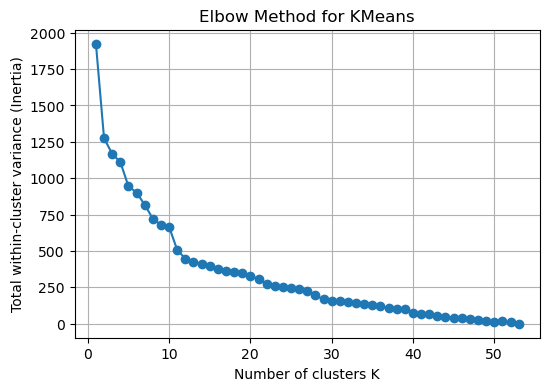

In [100]:
plt.figure(figsize=(6,4))
plt.plot(inertias['K'], inertias['Inertia'], marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Total within-cluster variance (Inertia)')
plt.title('Elbow Method for KMeans')
plt.grid(True)
plt.show()

Based on this we decided to make a function in which we can do the K-means clustering for different number of clusters, however, are main choices are 4, 5, and 11. We decided to do a K-means cluster for 4 cataogries because is is near one of the optimum points on the elbow graph and it matches the 4 census geographical regions. We decided to evaluate k=5 as well since it is right on an optimum point of the elbow graph. Lastly, we are going to look at k-means clustering with k=11, because it is the most optimum group size based on the elbow chart, however, 11 groups seems to be too many groups for the type of insight we are looking for from this grouping.

In [102]:
def plot_clusters(k, norm, print_table = False, color_by_region = False):
  '''
  k- number of clusters
  norm - normalized df
  print_table - print table of clusters (default is false)
  color_by_region - used to color states by CENSUS region instead of cluster
  '''
  km = sklearn.cluster.KMeans(n_clusters = k, n_init=10, random_state=1) #change random state for different centroid initailization
  labels = km.fit_predict(norm)

  clusters = pandas.DataFrame(labels, columns=['Cluster'], index = norm.index)
  clusters['State.Code'] = clusters.index
  clusters = clusters.sort_values('Cluster')
  clusters = clusters[['State.Code', 'Cluster']]
  clusters = clusters.reset_index(drop=True)

  if print_table:
    print(f'Cluster Assignments (k={k})')
    print(clusters)
    print('\n')

  pca = sklearn.decomposition.PCA(n_components = 2, svd_solver = 'full')
  tablePCA = pca.fit_transform(norm)
  tablePCA = pandas.DataFrame(tablePCA, index = norm.index, columns = ['X', 'Y'])
  tablePCA['State'] = tablePCA.index

  plot_data = pandas.merge(clusters, tablePCA, left_on = 'State.Code', right_on = 'State')
  if color_by_region:
    state_regions = pandas.DataFrame({
    "State": ["CO", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA",
    "IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD",
    "DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV", "AL", "KY", "MS", "TN", "AR",
    "LA", "OK", "TX",
    "AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA", "VI", "PR"],

    "Region": [
    "Northeast", "Northeast", "Northeast", "Northeast", "Northeast",
    "Northeast", "Northeast", "Northeast", "Northeast",

    "Midwest", "Midwest", "Midwest", "Midwest", "Midwest", "Midwest",
    "Midwest", "Midwest", "Midwest", "Midwest", "Midwest", "Midwest",

    "South", "South", "South", "South", "South", "South", "South",
    "South", "South", "South", "South", "South", "South", "South",
    "South", "South", "South",

    "West", "West", "West", "West", "West", "West", "West", "West",
    "West", "West", "West", "West", "West", "Territory", "Territory"
]
})

    plot_data = pandas.merge(plot_data, state_regions, left_on='State.Code', right_on='State')
    region_colors = {'Northeast': 'red', 'Midwest': 'blue', 'South': 'green', 'West': 'orange', 'Territory': 'purple'}
    for region, color in region_colors.items():
      subset = plot_data[plot_data['Region'] == region]
      plt.scatter(
        subset['X'],
        subset['Y'],
        color=color,
        label=region
    )
    plt.title("Comparison: Geographic Regions (Census Bureau)")
    plt.legend(title="Census Region", loc="best")

  else:
    scatter = plt.scatter(plot_data['X'], plot_data['Y'], c=plot_data['Cluster'], cmap = 'tab10')
    handles, labels = scatter.legend_elements(prop="colors")
    plt.legend(handles, labels, title="Cluster", loc="best")
    plt.title(f"PCA: Educational Similarity by State (k={k})")
  for i, row in plot_data.iterrows():
    plt.text(row['X'], row['Y'], row['State.Code'], fontsize=9, alpha=0.8)
  plt.xlabel("Principal Component 1")
  plt.ylabel("Principal Component 2")
  plt.grid(True, linestyle='--', alpha=0.5)
  #plt.show()

**Clustering K-Means with k = 4**

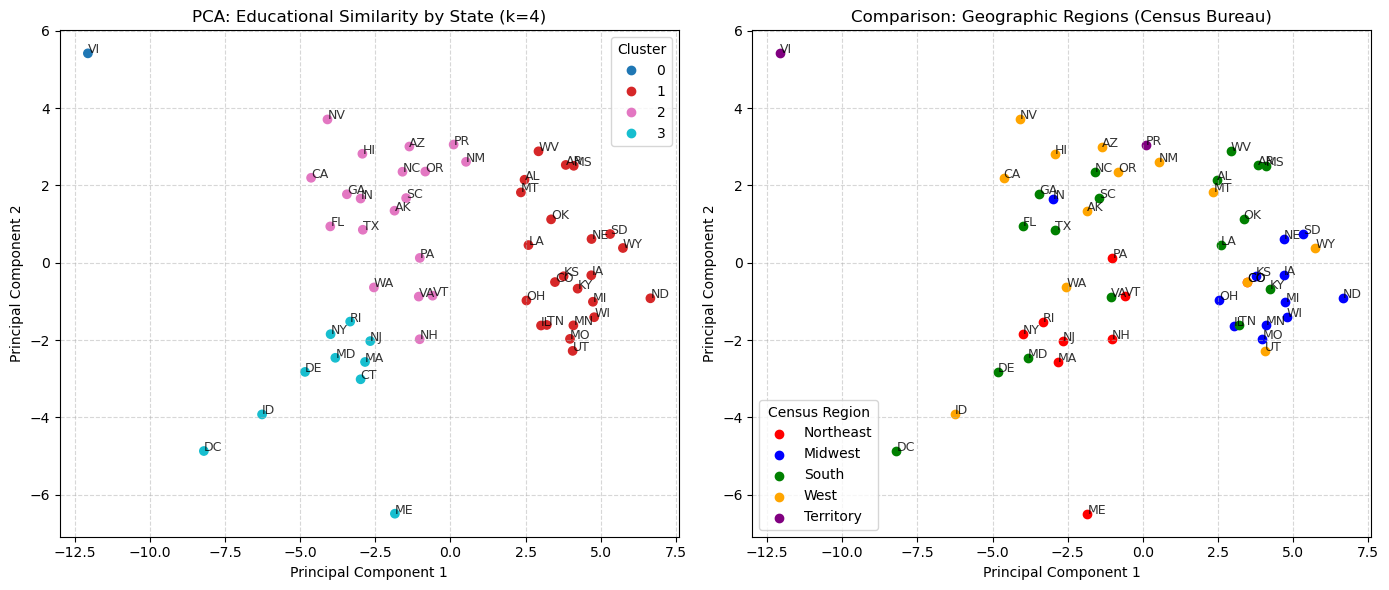

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])       # set current axis to left plot
plot_clusters(4, norm)

plt.sca(axes[1])       # set current axis to right plot
plot_clusters(4, norm, color_by_region=True)

plt.tight_layout()
plt.show()

Here, we notice that the clustering with 4 groups does not seem to be following the 4 Census geographical clusters. From this, we can also see some information about similarities/differences between states and regions. <br>
 - The Virgin Islands are very different from the rest of the states when looking at educational data and performance.
 - Schools in the Midwest are more similar to each other than schools in other regions.
 - Clusters 2 and 3 contain schools from mixed geographical regions.


**Clustering K-Means with k = 5**

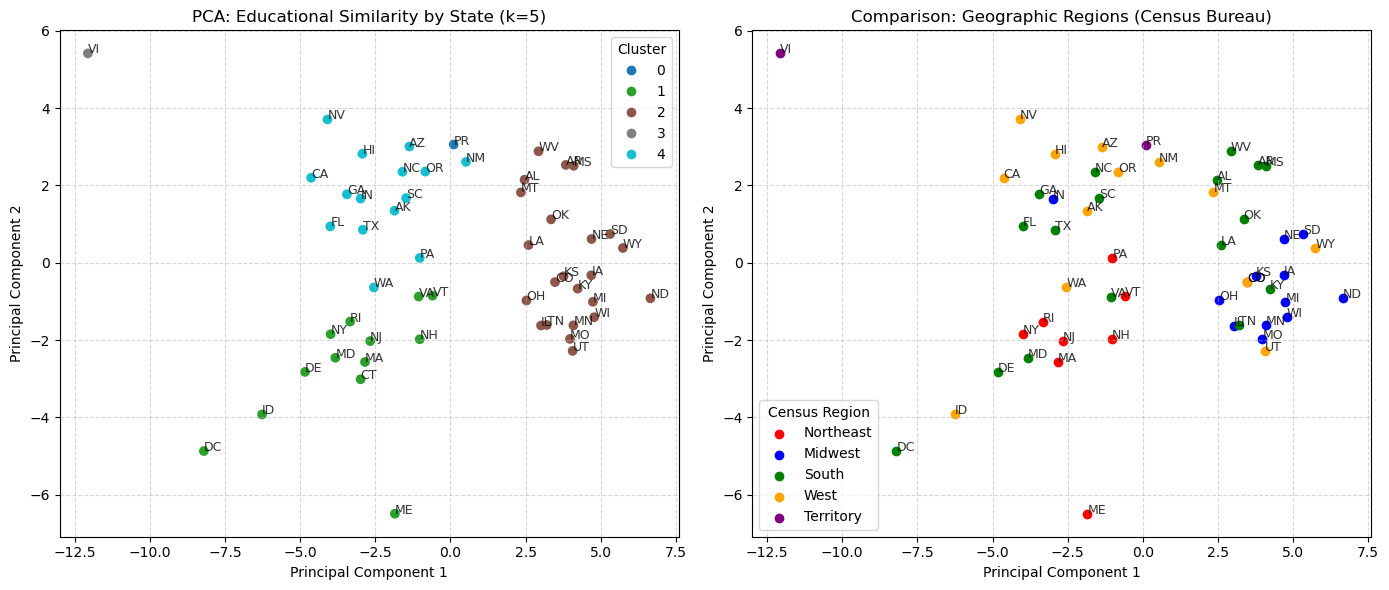

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])       # set current axis to left plot
plot_clusters(5, norm)

plt.sca(axes[1])       # set current axis to right plot
plot_clusters(5, norm, color_by_region=True)

plt.tight_layout()
plt.show()

This clustering result is very similar to that of k=4. The pattern in the Midwest schools remains. However, this time, both the Virgin Islands and Puerto Rico get their own clusters, versus last time only the Virgin Islands got its own cluster. 

- Here it is clearer that all but one state (Pennsylvania) classified as Northeast by the Census Bureau is also clustered together by the K-Means clustering algorithm based on educational data.

- Not all, but some (NV, HI, CA, AZ, OR, AK) of the schools classified as West were also in the same cluster

This supports that schools in the Northeast, Midwest, and West are similar to one another, following the Census Bureau geographical groupings. 


**Clustering K-Means with k=11**

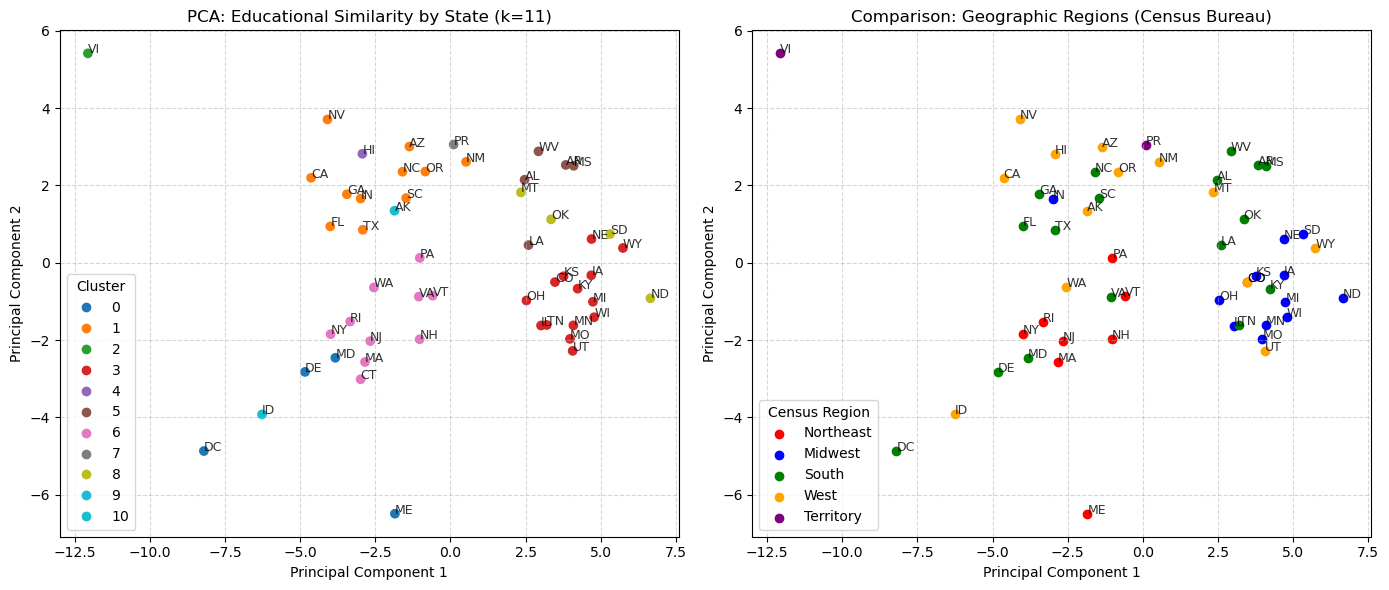

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])       # set current axis to left plot
plot_clusters(11, norm)

plt.sca(axes[1])       # set current axis to right plot
plot_clusters(11, norm, color_by_region=True)

plt.tight_layout()
plt.show()

As we assumed, it is difficult to make observations from this since there are so many groups. However, it is noticeable that the Northeast and Midwest pattern discussed above remains intact, but is less strong for the Northeast. Also, many more states are the only members of their clusters, namely Alaska, Idaho, and Hawaii, but there are still clusters that have a lot of members, such as Cluster 3, which contains a lot of the Midwest.


**Clustering Final Results**

We choose 5 clusters as the optimal number, offering enough clusters to reduce within-cluster variance while still allowing for practical interpretation. Thus, we have the clusters as follows:

- Illinois, Iowa, Kansas, Michigan, Minnesota, Missouri, Nebraska, North Dakota, Ohio, South Dakota, Wisconsin, Colorado, Montana, Utah, Wyoming, Alabama, Arkansas, Mississippi, Kentucky, Louisiana, Oklahoma, Tennessee, West Virginia (Midwest, Mountain West, Central South)
- Connecticut, Maine, Massachusetts, New Hampshire, New Jersey, New York, Rhode Island, Virginia, Vermont, Delaware, Maryland, Virginia, Washington DC, Idaho (Northeast, Upper South Atlantic, Idaho)
- Alaska, Arizona, California, Hawaii, Nevada, New Mexico, Oregon, Washington, Florida, Georgia, North Carolina, Texas, South Carolina, Indiana, Pennsylvania (Pacific West, Mexican Border States, Lower South Atlantic, Indiana, Pennsylvania)
- Puerto Rico
- US Virgin Islands


**Conclusions Based on the Data and Clustering Analysis**

From the data, it can be seen that the educational, demographic, and SAT data vary substantially across states. After merging SAT performance,
demographic indicators, income distributions, racial/ethnic proportions, and teacher employment data, we found that states differ along many 
simultaneous dimensions. This variation confirms that simple regional classifications cannot capture the full range of educational characteristics across the U.S., and makes clustering a natural next step.
To justify using 2015 demographic data with SAT predictors originally modeled using 2014 SAT scores, we compared linear regression models across both years. From this, we found:
- The R^2 values for 2014 and 2015 were nearly identical (0.798 vs 0.782)
- GPAs consistently explained ~78-80% of the variation in SAT scores across years
- While the overall predictive relationship is stable, individual subjects' coefficients shifted more strongly year to year
    
Using 2015 demographic data is reasonable and statistically supported, but interpretations at the subject level must acknowledge yearly variation

When projected into PCA space:
- Midwestern states cluster tightly together, indicating strong internal similarity in education demographics and SAT performance
- Northeastern states also were shown to form a more cohesive pattern than the South or the West
- Territories (VI, PR) consistently appear as outliers, highlighting their unique demographic and educational profiles

This dimensionality reduction previewed what clustering later confirmed: certain Census regions (especially Mthe idwest and Northeast) share educational similarities, but others do not

**Clustering Outcomes**

Clustering with k = 4 (chosen because it matches the number of Census divisions):
- Does not reproduce the Census regions
- States from many regions mix
- The Virgin Islands are a clear outlier, forming their own group and sitting far from other states
- Midwest states remain relatively close, but not exclusively so

From this, we can determine that educational characteristics do not break cleanly into four natural categories aligning with U.S. geographic regions

Clustering with k = 5 strengthens patterns:
- Northeast states cluster together more clearl,y with only one exception (Pennsylvania)
- Several western states (NV, HI, CA, AZ, OR, AK) also cluster together
- Midwest states remain cohesive similar to the k = 4 result
- Territories (PR, VI) each form their own clusters

From this we can determine that increasing cluster count slightly improves regional coherence, especially for the Northeast and some Western states, but mixed clusters continue to appear. This implies that while some regions share educational features, others differ significantly within the region

Clustering with k = 11 produces very fine-grained groupings with limited interpretability. Because the elbow curve suggested ~11 as an "optimal" point mathematically, we test k = 11 and found:
- Midwest still forms a recognizable pattern, but is now spread across several subclusters
- Northeast clustering signal remains visible, but it is weaker
- Many states became singletons (AK, HI, ID, etc.), each forming its own cluster
- Some clusters are disproportionately large, such as one containing much of the Midwest

From this, we determined that although k = 11 minimizes mathematical inertia, it produces too many clusters for practical interpretation, making it difficult to extract meaningful regional conclusions

**What clustering tells us about "data-driven regions"**

Across k = 4,5, and 11, several important patterns emerge:
- Some Census regions do reflect educational similarity:
    - Midwest: consistently forms one of the tightest clusters across all choices of k
    - Northeast: also tends to cluster together, especially at k=5
- Other Census regions are not educationally cohesive:
  - South and West regions show significant internal diversity
  - Western states range from extremely high performing (WA, OR) to outliers (AK, HI, AZ) that diverge from the group
- Territories and geographically isolated states also have been shown to behave very differently:
    - Virgin Islands, Puerto Rico, Alaska, Hawaii, and Idaho often end up in their own cluster or as extreme outliers
    - Their educational demographics differ enough that they rarely cluster with any contiguous U.S. groups.
- Educational regions do not map neatly onto political/geographic boundaries
- The clustering reveals cross-regional educational similarities. This can be seen in some Western and Northeastern states that cluster together more closely than they do with neighbors in their own Census region

**Overall Conclusions**

Educational characteristics across U.S. states do form meaningful patterns, but these patterns do not align cleanly with traditional Census 
regions. The Midwest and Northeast show the strongest internal similarity, while the South and West are far more heterogeneous and frequently overlap with other regions. Territories and isolated states behave uniquely and deserve separate consideration. $k = 5$ provides the most interpretable grouping, even though higher $k$ values may minimize mathematical error. Thus, data-driven clustering suggests that U.S. “educational regions” differ substantially from their geographic regions, reflecting a multidimensional set of academic, demographic, and socioeconomic drivers rather than geography alone.


**Limitations**

- The regions were created using data on SAT task takers and public school demographic data. There would likely be variation in the regions if more data were introduced (i.e., standardized test scores, comprehensive achievement/demographic data across all educational levels, student age distribution, etc.)
- The data used was only for the 2015-2016 school year; we don't know if the regions may experience shifts year-to-year or if they would stay consistent

**Potential Follow Up Questions**

- Given the Midwest has such a strong pattern, why is Indiana so different based on school education data and SAT performance?
- Do these regions hold for years other than 2015?
- Is there a statistical case that the educational demographics of island territories significantly differ from the mainland US?
- Do the educational regions have different SAT score predictors?


**Team Contribution Statement**  

Kathleen: Data Collection, Data Cleaning, Data Cleaning Comments and Challenges, Conclusions, Formatting

Evan: Model Stability Check

Cheyenne: Clustering

Ziad: Clustering

Hannah: Conclusions
